# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity.

The notebook starts in **sample mode** by default: it reads taxon IDs from the local IUCN spatial packages, then fetches IUCN Red List API v4 details only for those spatially relevant taxa. Switch `RUN_MODE` for other groups.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [125]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely scipy matplotlib

# Standard library
import importlib
import os, sys, time, json, re, glob, random, signal, subprocess
from pathlib import Path
from datetime import date
from collections import Counter, defaultdict

# Data & spatial
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import shape, Point
import scipy

# Visualisation
import matplotlib.pyplot as plt

# Web & progress
import requests
from tqdm.notebook import tqdm
from IPython.display import Image as IPImage, display, HTML

# Pipeline helpers (reloaded so edits to pipeline_helpers.py take effect)
import scripts.pipeline_helpers as ph
ph = importlib.reload(ph)
from scripts.pipeline_helpers import *

---
## 0 · Configuration

In [72]:
RUN_MODE = "full_other"  # one of "sample_mammals", "sample_birds", "sample_fish", "sample_other", "sample_marine_fish",
# "full_mammals", "full_other", "full_fish", "full_birds", or "full_marine_fish", or "full_molluscs"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")
IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
WIKIMEDIA_TOKEN_FILE = Path("data/secrets/wikimedia_token.txt")
WIKIMEDIA_TOKEN = os.getenv("WIKIMEDIA_TOKEN") or read_local_secret(WIKIMEDIA_TOKEN_FILE)

SLEEP_WIKI = 0.75
SLEEP_THUMBNAILS = 1.5   # slower: per-language REST endpoint has stricter limits        # seconds between Wikimedia action/REST API calls (~8.3 req/s, token-authenticated)
SLEEP_PAGEVIEWS = 2    # seconds between AQS pageviews calls (IP-based limit, token not honoured)
SLEEP_IUCN = 0.8    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = f"data/processed/animals_{RUN_MODE}.geojson"
MERGED_OUTPUT_PATH = os.path.normpath(os.path.join(os.path.dirname(OUTPUT_PATH), "..", "..", "animals.geojson"))
SPATIAL_DATA_DIR = "data/shapefiles"
BIRDS_FILTER_CSV = "data/filters/birds-filter-results.csv"
FULL_BIRDS_SIMPLIFIED = "data/processed/iucn_spatial_clean_full_birds_simplified.geojson"
if RUN_MODE.startswith("sample_"):
    _full_mode = RUN_MODE.replace("sample_", "full_", 1)
    _simplified = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
    _full = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    if os.path.exists(_simplified):
        CLEAN_SPATIAL_OUTPUT_PATH = _simplified
    elif os.path.exists(_full):
        CLEAN_SPATIAL_OUTPUT_PATH = _full
    else:
        CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
else:
    CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
CLEAN_SPATIAL_SIMPLIFIED_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}_simplified.geojson"
SIMPLIFY_TOLERANCE = 0.01  # degrees (~1 km)
CLEAN_SPATIAL_TARGETS_PATH = f"data/cache/checkpoints/ckpt_1_iucn_fetch_{RUN_MODE}.csv"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
OVERWRITE_SPATIAL_CLEAN = False        # Set to True to re-run spatial cleaning from raw shapefiles
OVERWRITE_SPATIAL_SIMPLIFICATION = False  # Set to True to re-simplify (e.g. when changing SIMPLIFY_TOLERANCE)
RUN_IUCN_FETCH = True       # Set to False to reload df from saved CSV and skip the API
MAX_RANGE_CENTROIDS_PER_SPECIES = 2
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.2
USE_IUCN_CACHE = True
USE_PARENT_SPATIAL_FALLBACK = False
GLOBAL_SCOPE_CODE = 1

dropped_log = []

ph.configure(
    IUCN_TOKEN=IUCN_TOKEN,
    WIKIMEDIA_TOKEN=WIKIMEDIA_TOKEN,
    USER_AGENT=USER_AGENT,
    TARGET_CATEGORIES=TARGET_CATEGORIES,
    SLEEP_WIKI=SLEEP_WIKI,
    SLEEP_PAGEVIEWS=SLEEP_PAGEVIEWS,
    SLEEP_IUCN=SLEEP_IUCN,
    SPATIAL_DATA_DIR=SPATIAL_DATA_DIR,
    SAMPLE_LIMIT=SAMPLE_LIMIT,
    USE_IUCN_CACHE=USE_IUCN_CACHE,
    USE_PARENT_SPATIAL_FALLBACK=USE_PARENT_SPATIAL_FALLBACK,
    BIRDS_FILTER_CSV=BIRDS_FILTER_CSV,
    GLOBAL_SCOPE_CODE=GLOBAL_SCOPE_CODE,
    IUCN_RED_LIST_VERSION=IUCN_RED_LIST_VERSION,
    IUCN_DATASET_CITATION=IUCN_DATASET_CITATION,
    SPATIAL_DATA_DOWNLOAD_DATE=SPATIAL_DATA_DOWNLOAD_DATE,
    IUCN_DATA_LAST_UPDATED=IUCN_DATA_LAST_UPDATED,
)

### Spatial cleaning

Reads the raw spatial files once, filters to threatened species, applies presence/seasonal filtering, and writes `iucn_spatial_clean_[mode].geojson`:
- **Birds**: keeps only taxa listed in the BirdLife filter CSV.
- **All other packages**: keeps only rows with a displayable IUCN category in the shapefile.

Skips automatically if the clean file already exists. Set `OVERWRITE_SPATIAL_CLEAN = True` to re-run from raw shapefiles.

In [11]:
packages = RUN_MODE_SPATIAL_PACKAGES[RUN_MODE]

if RUN_MODE.startswith("sample_") and CLEAN_SPATIAL_OUTPUT_PATH != f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson":
    print(f"{RUN_MODE}: reusing {CLEAN_SPATIAL_OUTPUT_PATH}")
elif not os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
    print(f"Clean file not found but OVERWRITE_SPATIAL_CLEAN=False — skipping (assuming simplified file exists): {CLEAN_SPATIAL_OUTPUT_PATH}")
elif os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
    print(f"Clean file already exists — skipping (set OVERWRITE_SPATIAL_CLEAN=True to overwrite): {CLEAN_SPATIAL_OUTPUT_PATH}")
else:
    ph.run_spatial_prefilter(
        packages=packages,
        output_path=CLEAN_SPATIAL_OUTPUT_PATH,
        birds_filter_csv=BIRDS_FILTER_CSV if "BIRDS" in packages else None,
    )

Clean file not found but OVERWRITE_SPATIAL_CLEAN=False — skipping (assuming simplified file exists): data/processed/iucn_spatial_clean_full_molluscs.geojson


### Geometry simplification

Spatial files can be several GB. Since only centroids are needed downstream, geometries are simplified to `SIMPLIFY_TOLERANCE` degrees (~1 km) and written to a separate `_simplified` file. All `full_*` modes run this step. `sample_*` modes skip it and reuse the corresponding `full_*` simplified file.

Skips automatically if the simplified file already exists. Set `OVERWRITE_SPATIAL_SIMPLIFICATION = True` to re-run (e.g. after changing `SIMPLIFY_TOLERANCE`).

In [7]:
# Determine source and output paths for simplification
if RUN_MODE.startswith('sample_'):
    _full_mode = RUN_MODE.replace('sample_', 'full_', 1)
    _simplify_input  = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    _simplify_output = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
else:
    _simplify_input  = CLEAN_SPATIAL_OUTPUT_PATH
    _simplify_output = CLEAN_SPATIAL_SIMPLIFIED_PATH

if not os.path.exists(_simplify_input):
    print(f"Simplification skipped — source file not found: {_simplify_input}")
elif os.path.exists(_simplify_output) and not OVERWRITE_SPATIAL_SIMPLIFICATION:
    print(f"Simplified file already exists — skipping (set OVERWRITE_SPATIAL_SIMPLIFICATION=True to redo): {_simplify_output}")
else:
    os.environ['OGR_GEOJSON_MAX_OBJ_SIZE'] = '0'
    before_size = os.path.getsize(_simplify_input) / 1e6
    print(f"Loading {_simplify_input} ({before_size:.0f} MB) for simplification...")
    gdf = gpd.read_file(_simplify_input)
    gdf['geometry'] = gdf.geometry.simplify(SIMPLIFY_TOLERANCE, preserve_topology=True)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf.to_file(_simplify_output, driver='GeoJSON')
    after_size = os.path.getsize(_simplify_output) / 1e6
    print(f"Simplified: {before_size:.0f} MB → {after_size:.0f} MB ({after_size/before_size*100:.1f}%)")
    print(f"Written: {_simplify_output}")

Loading data/processed/iucn_spatial_clean_full_molluscs.geojson (3063 MB) for simplification...
Simplified: 3063 MB → 609 MB (19.9%)
Written: data/processed/iucn_spatial_clean_full_molluscs_simplified.geojson


In [8]:
# Count total and endangered taxa across all available simplified spatial files
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"

_simplified_files = sorted(glob.glob("data/processed/iucn_spatial_clean_full_*_simplified.geojson"))
if not _simplified_files:
    print("No simplified spatial files found in data/processed/")
else:
    _ENDANGERED_CATS = {"EW", "CR", "EN", "VU", "NT", "CD"}
    _all_taxa = {}  # taxonid -> category
    for _path in _simplified_files:
        _mode = os.path.basename(_path).replace("iucn_spatial_clean_full_", "").replace("_simplified.geojson", "")
        _gdf = ph.load_clean_spatial_file(_path)
        _n_total = _gdf["taxonid"].nunique()
        _n_endangered = _gdf[_gdf["spatial_category"].isin(_ENDANGERED_CATS)]["taxonid"].nunique()
        for _, row in _gdf.drop_duplicates(subset="taxonid").iterrows():
            _all_taxa[row["taxonid"]] = row.get("spatial_category", "")
        print(f"  {_mode:20s}  {_n_total:>5,} taxa total  |  {_n_endangered:>5,} endangered")

    _total = len(_all_taxa)
    _total_endangered = sum(1 for v in _all_taxa.values() if v in _ENDANGERED_CATS)
    print(f"{'─'*55}")
    print(f"  {'ALL MODES':20s}  {_total:>5,} taxa total  |  {_total_endangered:>5,} endangered")

  birds                 2,214 taxa total  |      0 endangered
  fish                  4,478 taxa total  |  4,478 endangered
  mammals               1,764 taxa total  |  1,764 endangered
  marine_fish             299 taxa total  |    299 endangered
  molluscs              1,577 taxa total  |  1,577 endangered
  other                 6,168 taxa total  |  6,168 endangered
───────────────────────────────────────────────────────
  ALL MODES             16,352 taxa total  |  14,138 endangered


---
## 1 · Species list

Fetches IUCN Red List API v4 details for taxa present in the local spatial packages. Run mode controls which packages are used.

**Caching:** individual API responses are cached in `data/cache/iucn/`. Set `RUN_IUCN_FETCH = False` to skip the fetch loop entirely and reload the last run's output from `data/cache/checkpoints/`.

**Subspecies nuance:** only shapefile taxa with displayable IUCN categories are fetched. If `USE_PARENT_SPATIAL_FALLBACK = True`: threatened infrarank children absent from the shapefiles are displayed using their parent species geometry as a spatial lookup source. Disabled by default. Non-threatened parent taxa (LC/DD/NE) are not fetched to avoid heavy API calls, so infrarank children that would only be reachable through them (not present in shapefiles) are silently ignored.

### IUCN API call

In [9]:
# Two caching layers:
#   1. Per-request cache in data/cache/iucn/ (pipeline_helpers.py, always active):
#      each IUCN API call is hashed and stored as JSON — individual requests are
#      served from disk if already seen, so re-running only fetches new taxa.
#   2. Full-run cache below (this cell): if RUN_IUCN_FETCH=False and the CSV
#      from the last run exists (saved by cell 14), skip the fetch loop entirely.

if not RUN_IUCN_FETCH and os.path.exists(CLEAN_SPATIAL_TARGETS_PATH):
    df = pd.read_csv(CLEAN_SPATIAL_TARGETS_PATH)
    print(f"Loaded {len(df):,} taxa from {CLEAN_SPATIAL_TARGETS_PATH} (API fetch skipped)")
else:
    print("Building the list of taxa to fetch based on spatial files...")
    _manifest_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
    spatial_manifest = ph.spatial_manifest_from_clean_file(_manifest_path, RUN_MODE)
    df = fetch_iucn_species_from_spatial_manifest(spatial_manifest)
    print(f"{RUN_MODE} mode before dedup: {len(df):,} display taxa from IUCN")

df.head()

# Track taxa seeded from spatial manifest but not retained after IUCN fetch + selection
if RUN_IUCN_FETCH and 'spatial_manifest' in dir():
    _seeded_ids = set(spatial_manifest["taxonid"].astype(int))
    ph.log_dropped(dropped_log, _seeded_ids, df["taxonid"].astype(int), "iucn_api_fetch",
                "not fetched or not displayable (wrong category, no assessment, or filtered)", df)
    print(f"  dropped_log total: {len(dropped_log)} taxa")


Building the list of taxa to fetch based on spatial files...
Spatial manifest from clean file: 1,577 taxa (full_molluscs)


Fetch IUCN from spatial IDs:   0%|          | 0/1577 [00:00<?, ?it/s]

IUCN spatial-package fetch summary
- Spatial seed taxa fetched from API: 1,577
- Display rows kept: 1,577 (1,577 direct shapefile taxa + 0 children using parent geometry)
- Missing-spatial child candidates tested from displayable parents: 0
- Missing-spatial children added with parent geometry: 0
- Parent rows not used for child discovery after API validation: 0
- Self rows skipped by shapefile category prefilter: 0
- Child/self rows skipped after API detail: 0 (none)
- Duplicate rows ignored: 0
full_molluscs mode before dedup: 1,577 display taxa from IUCN
  dropped_log total: 0 taxa


### Species vs. subspecies selection

In [12]:
if RUN_IUCN_FETCH:
    # Parent species removed here are not displayed, but child rows keep parent_taxonid
    # and spatial_lookup_taxonid so later spatial/Wikidata fallbacks can still use the parent.
    print(f"Fetched rows: {len(df):,}; unique taxa: {df.taxonid.nunique():,}")
    
    if "spatial_lookup_source" in df.columns:
        print(df["spatial_lookup_source"].fillna("Unknown").value_counts().to_string())
    
    if {"category", "spatial_category", "spatial_lookup_source"}.issubset(df.columns):
        direct_rows = df[df["spatial_lookup_source"].eq("self")].copy()
        direct_mismatches = direct_rows[direct_rows["category"].fillna("Unknown") != direct_rows["spatial_category"].fillna("Unknown")]
        print(
            f"\nDirect shapefile taxa with API category different from shapefile category: "
            f"{len(direct_mismatches):,} / {len(direct_rows):,}"
        )
        if not direct_mismatches.empty:
            display(
                direct_mismatches[["taxonid", "scientific_name", "main_common_name", "category", "spatial_category"]]
                .head(20)
            )
    
    # Normalise CD -> NT for display, deduplicate on taxonid, then prefer fetched
    # endangered infraranks over their parent species.
    df["category_iucn"] = df["category"].replace("CD", "NT")
    df = df.drop_duplicates(subset="taxonid").copy()
    before_selection = len(df)
    df = replace_species_with_available_infraranks(df)
    removed_parents = before_selection - len(df)
    print(f"\nAfter species vs. subspecies selection: {len(df):,} rows ({removed_parents:,} parent species removed)")
    
    print("\nEndangered category balance after selection:")
    print(df["category_iucn"].value_counts().to_string())
    if "taxon_rank" in df.columns:
        print("\ntaxon_rank after selection:")
        print(df["taxon_rank"].fillna("Unknown").value_counts().to_string())
    if "taxon_group" in df.columns:
        print("\ntaxon_group after selection:")
        print(df["taxon_group"].fillna("Unknown").value_counts().to_string())
    
    df.head()
else:
    print(f"Species/subspecies selection skipped — using saved CSV ({df['taxon_rank'].value_counts().to_string() if 'taxon_rank' in df.columns else ''})")

Fetched rows: 1,577; unique taxa: 1,577
spatial_lookup_source
self    1577

Direct shapefile taxa with API category different from shapefile category: 0 / 1,577
Species vs. subspecies selection: 5 species list infrarank children, but no fetched/displayable child had an endangered category; parent species kept

After species vs. subspecies selection: 1,577 rows (0 parent species removed)

Endangered category balance after selection:
category_iucn
EN    511
VU    460
CR    313
NT    293

taxon_rank after selection:
taxon_rank
species    1577

taxon_group after selection:
taxon_group
Crustaceans, Molluscs (not comprehensive)    1577


### Save checkpoint

In [13]:
# ── Checkpoint 1: after IUCN fetch ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df.to_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 1 saved — IUCN fetch: df.shape={df.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 1 saved — IUCN fetch: df.shape=(1577, 25), dropped_log=0 taxa


In [14]:
# ── Restart from checkpoint 1 ──
# Run this cell instead of all cells above to resume from after iucn_fetch.
_ckpt_dir = "data/cache/checkpoints"
df = pd.read_csv(f"{_ckpt_dir}/ckpt_1_iucn_fetch_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_1_iucn_fetch_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 1 (iucn_fetch): {df.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 1 (iucn_fetch): (1577, 25), dropped_log=0 taxa


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The difference is which local IUCN spatial packages seed `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with the configured `RANGE_CLUSTER_BUFFER_KM`, always keep the largest cluster, then keep secondary clusters only when they pass `SECONDARY_RANGE_CLUSTER_MIN_SHARE`, capped by `MAX_RANGE_CENTROIDS_PER_SPECIES`.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from explicit `spatial_package` values; `taxon_class` is kept only as API metadata.
- This keeps package concepts separate from taxonomy concepts: for example, `FW_FISH` is not the same thing as the whole class `Actinopterygii`.
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.


In [15]:
# Load file
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"
# Quick re-filter: keep only taxa confirmed by the IUCN API
target_ids = set(df["taxonid"].astype(int))
spatial_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
print(f"Loading spatial file: {spatial_path}")
gdf_all = load_clean_spatial_file(spatial_path)
gdf_all = gdf_all[gdf_all["taxonid"].astype(int).isin(target_ids)].copy()
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"
_ids_with_geometry = set(gdf_all["taxonid"].astype(int))
ph.log_dropped(dropped_log, target_ids, _ids_with_geometry, "spatial_join",
            "no spatial geometry in clean file", df)
print(f"  dropped_log total: {len(dropped_log)} taxa")

Loading spatial file: data/processed/iucn_spatial_clean_full_molluscs_simplified.geojson
  dropped_log total: 0 taxa


### Parent species spatial fallback

This cell looks only at parent species from which spatial information will be propagated to displayed subspecies that were not initially present in the spatial files.

Parents remain lookup sources, never additional displayed animals. The fallback is deliberately narrow: it only applies to rows already routed to parent geometry during the IUCN fetch, then copies matched parent polygons/points onto those displayed subspecies.


In [16]:
if USE_PARENT_SPATIAL_FALLBACK:
    # Parent-species spatial fallback. This intentionally runs after the self-geometry load:
    # we only clean parent geometries for rows already routed to parent geometry in section 1.
    # Parents remain lookup sources, never displayed taxa.
    display_taxa = df.drop_duplicates(subset="taxonid").copy()
    display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
    display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
    uses_parent_lookup = display_taxa.get("spatial_lookup_source").eq("parent_species") if "spatial_lookup_source" in display_taxa.columns else pd.Series(False, index=display_taxa.index)
    if "spatial_lookup_taxonid" in display_taxa.columns:
        parent_lookup_from_fetch = pd.to_numeric(display_taxa["spatial_lookup_taxonid"], errors="coerce")
        display_taxa.loc[display_taxa["parent_taxonid_numeric"].isna() & uses_parent_lookup, "parent_taxonid_numeric"] = parent_lookup_from_fetch
    self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
    parent_fallback_links = display_taxa[
        display_taxa["parent_taxonid_numeric"].notna()
        & uses_parent_lookup
        & ~display_taxa["taxonid"].isin(self_spatial_taxa)
    ][["taxonid", "parent_taxonid_numeric", "spatial_package"]].drop_duplicates()
    
    if parent_fallback_links.empty:
        pass
    else:
        parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
        parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
        parent_targets = (
            parent_fallback_links[["parent_taxonid", "spatial_package"]]
            .drop_duplicates()
            .rename(columns={"parent_taxonid": "taxonid"})
        )
        parent_targets["category_iucn"] = None
        parent_targets["scientific_name"] = None
        parent_targets = parent_targets[["taxonid", "spatial_package", "category_iucn", "scientific_name"]]
        parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)
    
        parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
        if RUN_SPATIAL_CLEANING:
            parent_cleaning_available = False
            try:
                run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH, SPATIAL_DATA_DIR)
                parent_cleaning_available = True
            except subprocess.CalledProcessError:
                print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
        else:
            print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")
    
        if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
            parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
            fallback_frames = []
            for link in parent_fallback_links.itertuples(index=False):
                parent_id = int(link.parent_taxonid)
                child_id = int(link.taxonid)
                parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
                if parent_rows.empty:
                    continue
                parent_rows["spatial_lookup_taxonid"] = parent_id
                parent_rows["spatial_lookup_source"] = "parent_species"
                parent_rows["taxonid"] = child_id
                fallback_frames.append(parent_rows)
            if fallback_frames:
                fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
                gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
            else:
                pass


### Compute centroids from polygons (then from observation points)

In [17]:
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")

gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

In [18]:
# Simplify vertices when too heavy

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)

# Simplify heavy polygon parts before dissolve + centroid computation.
CENTROID_SIMPLIFY_THRESHOLD = 10_000   # vertices above which we re-simplify
CENTROID_SIMPLIFY_TOLERANCE = 0.1      # degrees (~10 km) — fine for centroid purposes

if not polygon_gdf.empty:
    _vertex_counts = polygon_gdf["geometry"].map(ph.geometry_vertex_count)
    _heavy = _vertex_counts > CENTROID_SIMPLIFY_THRESHOLD
    _pre_simplify_vertices = {}  # taxonid -> total vertices before simplification
    if _heavy.any():
        for _tid, _grp in polygon_gdf[_heavy].groupby("taxonid"):
            _pre_simplify_vertices[_tid] = int(_grp["geometry"].map(ph.geometry_vertex_count).sum())
        polygon_gdf.loc[_heavy, "geometry"] = polygon_gdf.loc[_heavy, "geometry"].map(
            lambda g: g.simplify(CENTROID_SIMPLIFY_TOLERANCE, preserve_topology=True)
        )
        _post = polygon_gdf.loc[_heavy, "geometry"].map(ph.geometry_vertex_count)
        print(f"Pre-dissolve simplification ({CENTROID_SIMPLIFY_TOLERANCE}°): {_heavy.sum()} parts "
              f"across {len(_pre_simplify_vertices)} taxa — "
              f"vertices {sum(_pre_simplify_vertices.values()):,} → {int(_post.sum()):,} "
              f"({100*(1 - _post.sum()/_vertex_counts[_heavy].sum()):.0f}% reduction)")
    else:
        _pre_simplify_vertices = {}

Pre-dissolve simplification (0.1°): 261 parts across 260 taxa — vertices 9,425,683 → 4,572,465 (51% reduction)


In [19]:
# Prepare spatial data

spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    polygon_gdf["geometry"] = polygon_gdf["geometry"].map(make_valid)
    polygon_gdf = polygon_gdf[polygon_gdf.geometry.notna() & ~polygon_gdf.geometry.is_empty].copy()
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

In [20]:
# Geometry complexity table for all rows in gdf_all

def _geom_stats(geom):
    parts = list(geom.geoms) if hasattr(geom, 'geoms') else [geom]
    n_parts = len(parts)
    n_vertices = sum(
        len(p.exterior.coords) + sum(len(i.coords) for i in p.interiors)
        for p in parts if hasattr(p, 'exterior')
    )
    return n_parts, n_vertices

rows = []
for idx, row in range_geometries.iterrows():
    n_parts, n_vertices = _geom_stats(row.geometry)
    rows.append({
        "row": idx,
        "taxonid": row.taxonid,
        "parts": n_parts,
        "vertices": n_vertices,
    })

complexity = pd.DataFrame(rows).sort_values("row")
#complexity.style.background_gradient(subset=["parts", "vertices"], cmap="YlOrRd").format({"vertices": "{:,}"})

In [21]:
# Compute centroids
import signal

CENTROID_CLUSTER_TIMEOUT = 60  # seconds before falling back to largest-part centroid

def _handle_centroid_timeout(signum, frame):
    raise TimeoutError("cluster_range_parts timed out")
signal.signal(signal.SIGALRM, _handle_centroid_timeout)

centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    _verts = ph.geometry_vertex_count(row.geometry)
    tqdm.write(f"  taxonid={row.taxonid}  parts={len(parts)}  vertices={_verts:,}")
    total_components = len(parts)
    signal.alarm(CENTROID_CLUSTER_TIMEOUT)
    try:
        cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
        signal.alarm(0)
    except TimeoutError:
        signal.alarm(0)
        tqdm.write(f"  ⚠ taxonid={row.taxonid} timed out after {CENTROID_CLUSTER_TIMEOUT}s — using largest-part centroid")
        _largest = max(parts, key=lambda g: g.area)
        _pt = safe_centroid(_largest)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": _pt,
            "lon": _pt.x,
            "lat": _pt.y,
            "centroid_source": "range_polygon",
            "centroid_rank": 1,
            "centroid_count": 1,
            "range_component_count": total_components,
            "range_cluster_count": 1,
            "range_cluster_component_count": 1,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": 1.0,
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": None,
            "computed_range_component_area_km2": None,
            "range_component_area_km2": None,
            "observation_point_count": None,
        })
        continue
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count",
    "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df["taxonid"] = df["taxonid"].astype(int)
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
ph.log_dropped(dropped_log, df_base["taxonid"].astype(int), df["taxonid"].astype(int),
            "centroid_merge", "no centroid computed (no polygon or point geometry matched)", df_base)
print(f"  dropped_log total: {len(dropped_log)} taxa")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")
secondary = df[df["centroid_rank"].fillna(1).astype(int) > 1]
print(f"Of which, secondary centroid points kept: {len(secondary):,}")

Range polygon centroids:   0%|          | 0/1577 [00:00<?, ?it/s]

  taxonid=315  parts=15  vertices=735
  taxonid=618  parts=1  vertices=16
  taxonid=619  parts=1  vertices=392
  taxonid=774  parts=2  vertices=282
  taxonid=775  parts=53  vertices=1,796
  taxonid=776  parts=1  vertices=165
  taxonid=781  parts=211  vertices=5,763
  taxonid=980  parts=1  vertices=173
  taxonid=1262  parts=1  vertices=50
  taxonid=1291  parts=1  vertices=23
  taxonid=1295  parts=1  vertices=9
  taxonid=1296  parts=1  vertices=11
  taxonid=1312  parts=2  vertices=728
  taxonid=2092  parts=1  vertices=71
  taxonid=2114  parts=2  vertices=262
  taxonid=2420  parts=2  vertices=73
  taxonid=2681  parts=1  vertices=9
  taxonid=2686  parts=1  vertices=9
  taxonid=2690  parts=1  vertices=9
  taxonid=2693  parts=1  vertices=9
  taxonid=2694  parts=1  vertices=9
  taxonid=2697  parts=1  vertices=5
  taxonid=2702  parts=1  vertices=9
  taxonid=2703  parts=1  vertices=9
  taxonid=2704  parts=1  vertices=9
  taxonid=2711  parts=1  vertices=9
  taxonid=2713  parts=1  vertices=10
  t

Fallback point centroids: 0it [00:00, ?it/s]

  dropped_log total: 0 taxa
Output label points with spatial data: 1,621 from 1,577 species
Of which, secondary centroid points kept: 44


In [22]:
#range_geometries[range_geometries['taxonid'] == 169783]

taxonid:  2686
presence: 1  |  seasonal: 1

Individual polygon rows in polygon_gdf (pre-dissolve): 1
MultiPolygon components after dissolve:                1

No simplification applied (below 10,000-vertex threshold)
  vertices: 9


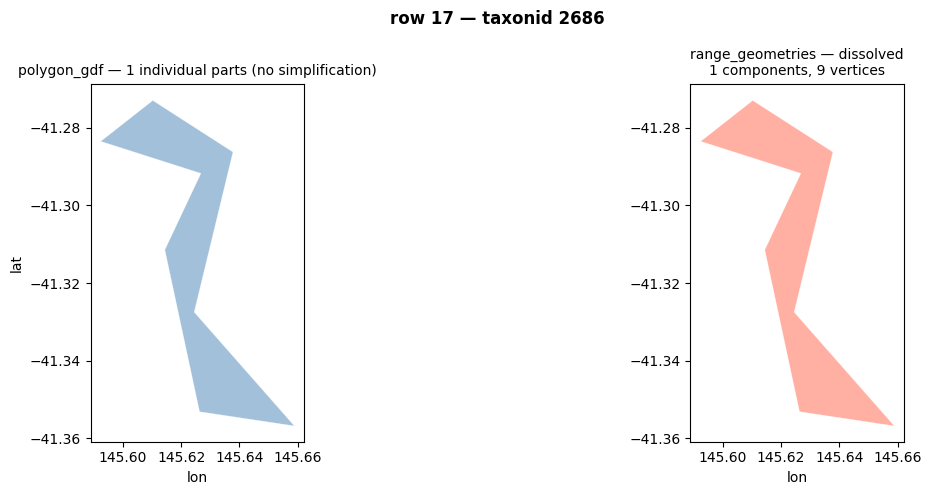

In [27]:
# Inspect a row from range_geometries (by integer index)
INSPECT_ROW = 17

row = range_geometries.iloc[INSPECT_ROW]
tid = row.taxonid
parts_dissolved = list(row.geometry.geoms) if hasattr(row.geometry, 'geoms') else [row.geometry]
parts_raw = polygon_gdf[polygon_gdf["taxonid"] == tid]

n_vertices_before = _pre_simplify_vertices.get(tid)  # None if not simplified
n_vertices_after  = sum(len(p.exterior.coords) + sum(len(i.coords) for i in p.interiors)
                        for p in parts_dissolved if hasattr(p, "exterior"))

print(f"taxonid:  {tid}")
print(f"presence: {getattr(row, 'spatial_presence', '—')}  |  seasonal: {getattr(row, 'spatial_seasonal', '—')}")
print()
print(f"Individual polygon rows in polygon_gdf (pre-dissolve): {len(parts_raw)}")
print(f"MultiPolygon components after dissolve:                {len(parts_dissolved)}")
print()
if n_vertices_before is not None:
    reduction = 100 * (1 - n_vertices_after / n_vertices_before)
    print(f"Simplification applied at {CENTROID_SIMPLIFY_TOLERANCE}°:")
    print(f"  vertices before: {n_vertices_before:,}")
    print(f"  vertices after:  {n_vertices_after:,}  ({reduction:.0f}% reduction)")
else:
    print(f"No simplification applied (below {CENTROID_SIMPLIFY_THRESHOLD:,}-vertex threshold)")
    print(f"  vertices: {n_vertices_after:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parts_raw.plot(ax=axes[0], color="steelblue", alpha=0.5, edgecolor="white", linewidth=0.4)
simplified_label = f"simplified to {CENTROID_SIMPLIFY_TOLERANCE}°" if n_vertices_before else "no simplification"
axes[0].set_title(
    f"polygon_gdf — {len(parts_raw)} individual parts ({simplified_label})", fontsize=10)
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

gpd.GeoDataFrame(geometry=[row.geometry], crs="EPSG:4326").plot(
    ax=axes[1], color="tomato", alpha=0.5, edgecolor="white", linewidth=0.4)
before_str = f"{n_vertices_before:,} → " if n_vertices_before else ""
axes[1].set_title(
    f"range_geometries — dissolved\n"
    f"{len(parts_dissolved)} components, {before_str}{n_vertices_after:,} vertices", fontsize=10)
axes[1].set_xlabel("lon")

fig.suptitle(f"row {INSPECT_ROW} — taxonid {tid}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [46]:
df.shape

(6230, 49)

### Explore taxa that produced several spatial label points

Taxa with several label points: 44


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
452,133619,Lobophyllia diminuta,Lobed Cactus Coral,EN,2,range_polygon,Extant,Resident,57,6,200,1.076390e+07
255,133093,Alveopora daedalea,NaN,EN,2,range_polygon,Extant,Resident,41,5,200,8.771623e+06
264,133117,Montipora lobulata,NaN,EN,2,range_polygon,Extant,Resident,90,9,200,6.423228e+06
425,133534,Pocillopora zelli,NaN,EN,2,range_polygon,Extant,Resident,36,6,200,5.415368e+06
236,133045,Pocillopora ligulata,NaN,EN,2,range_polygon,Extant,Resident,112,12,200,4.921042e+06
463,133663,Madracis decactis,Ten-ray Star Coral,CR,2,range_polygon,Extant,Resident,11,7,200,3.827415e+06
396,133471,Acropora bushyensis,NaN,EN,2,range_polygon,Extant,Resident,67,4,200,3.258604e+06
315,133255,Agaricia humilis,Lowrelief Lettuce Coral,CR,2,range_polygon,Extant,Resident,7,4,200,3.243108e+06
212,132981,Acropora hemprichii,NaN,EN,2,range_polygon,Extant,Resident,36,2,200,3.233718e+06
290,133187,Porites arnaudi,NaN,NT,2,range_polygon,Extant,Resident,44,5,200,3.173771e+06


Exploring taxonid: 133619


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
481,133619,Lobophyllia diminuta,Lobed Cactus Coral,EN,1,2,range_polygon,141.854481,-10.340821,6.111777e+06,1.076390e+07,57,6,21,200,0.567803,Extant,Resident
482,133619,Lobophyllia diminuta,Lobed Cactus Coral,EN,2,2,range_polygon,106.019276,9.216489,2.372845e+06,1.076390e+07,57,6,16,200,0.220445,Extant,Resident


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,6.111777e+06,0.567803,21,True
1,2,2.372845e+06,0.220445,16,True
2,3,1.748342e+06,0.162426,14,False
3,4,4.203303e+05,0.039050,3,False
4,5,6.891304e+04,0.006402,1,False
5,6,4.169185e+04,0.003873,2,False


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
27012,133619,5.075399e+06,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27011,133619,1.010200e+06,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27010,133619,7.172580e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27009,133619,5.690228e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27008,133619,4.287477e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27007,133619,4.093234e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27006,133619,2.862327e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27004,133619,2.448925e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27005,133619,2.140551e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp
27003,133619,2.121893e+05,Extant,Resident,REEF_FORMING_CORALS_PART1.shp


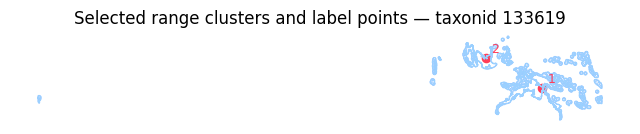

In [28]:
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = None
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


### Save checkpoint

In [29]:
# ── Checkpoint 2: after Centroids ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df.to_csv(f"{_ckpt_dir}/ckpt_2_centroids_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_2_centroids_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 2 saved — Centroids: df.shape={df.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 2 saved — Centroids: df.shape=(1621, 49), dropped_log=0 taxa


In [30]:
# ── Restart from checkpoint 2 ──
# Run this cell instead of all cells above to resume from after centroids.
_ckpt_dir = "data/cache/checkpoints"
df = pd.read_csv(f"{_ckpt_dir}/ckpt_2_centroids_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_2_centroids_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 2 (centroids): {df.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 2 (centroids): (1621, 49), dropped_log=0 taxa


---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [31]:
print("Wikidata language priority:", ", ".join(WIKIPEDIA_LANGUAGE_PRIORITY))

Wikidata language priority: en, de, ja, fr, es, ru, it, zh, pt, pl, nl, uk, ca, sv, cs, fi, ko, tr, no, da, eo


In [32]:
# Wikidata batch fetch
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)

Wikidata batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [33]:
# Name-based fallback: taxa whose IUCN taxon ID isn't linked in Wikidata
# (e.g. Catopuma temminckii stored as Pardofelis temminckii, or missing P627)
WIKIDATA_NAME_CACHE_PATH = f"data/cache/wikidata/name_fallback_{RUN_MODE}.json"

unresolved_ids = list(dict.fromkeys(str(t) for t in wikidata_taxon_ids if str(t) not in wikidata_map))
if unresolved_ids:
    name_fallback = ph.query_wikidata_by_names(unresolved_ids, df, cache_path=WIKIDATA_NAME_CACHE_PATH)
    wikidata_map.update(name_fallback)

ph.configure(wikidata_map=wikidata_map)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)

  Wikidata name cache: 52 found + 0 not-found entries loaded from data/cache/wikidata/name_fallback_full_molluscs.json
Wikidata name fallback: 343 unique taxa unresolved
  Pass 1 (P225): resolved 170 / 343 — 173 remaining for per-taxon search
  [1/173] Obovaria choctawensis ... [wbsearch HTTP error: 502 Server Error: Bad Gateway for url: https://query.wikidata.org/sparql] http error — will retry
  [2/173] Vitta rubricata ... [wbsearch HTTP error: 502 Server Error: Bad Gateway for url: https://query.wikidata.org/sparql] found
  [3/173] Moitessieria calloti ... found
  [4/173] Moitessieria heideae ... found
  [5/173] Hydrobia guyenoti ... not found
  [6/173] Mutela franci ... not found
  [7/173] Lymnaea ovalior ... not found
  [8/173] Rhombuniopsis tauriformis ... not found
  [9/173] Cipangopaludina dianchiensis ... not found
  [10/173] Lamprotula crassa ... not found
  [11/173] Lamprotula liedtkei ... not found
  [12/173] Lamprotula nodulosa ... not found
  [13/173] Lamprotula ponderosa

en     526
nl     400
ceb    236
fr     180
bg      27
sv      19
es       5
war      4
pl       4
zh       3
Name: count, dtype: int64

In [34]:
# Remove taxa that share a wiki_url: two IUCN taxa resolving to the same
# Wikipedia article is ambiguous. Treated as not found — shown on globe
# without a Wikipedia link, popularity imputed to 1.

# WARNING: NO NEED FOR MAMMALS (3 cases are legit) NOR BIRDS NOR MARINE FISH (no cases)

_url_to_tids = {}
for tid, v in wikidata_map.items():
    url = v.get("wiki_url")
    if url:
        _url_to_tids.setdefault(url, []).append(tid)

_shared = {url: tids for url, tids in _url_to_tids.items() if len(tids) > 1}
_tids_to_remove = [tid for tids in _shared.values() for tid in tids]
for tid in _tids_to_remove:
    del wikidata_map[tid]

ph.configure(wikidata_map=wikidata_map)
ph.log_dropped(dropped_log, {int(t) for t in _tids_to_remove}, set(),
               "shared_wiki_url", "Multiple IUCN taxa resolved to the same Wikipedia article", df)
print(f"Removed {len(_tids_to_remove)} taxa sharing a wiki_url ({len(_shared)} duplicate URLs)")
for url, tids in sorted(_shared.items(), key=lambda x: -len(x[1])):
    names = [df.loc[df["taxonid"].astype(str)==tid, "scientific_name"].iloc[0]
             if (df["taxonid"].astype(str)==tid).any() else tid for tid in tids]
    print(f"  {url}")
    for n in names:
        print(f"    - {n}")

  [shared_wiki_url] 4 taxa dropped: Multiple IUCN taxa resolved to the same Wikipedia article
Removed 4 taxa sharing a wiki_url (1 duplicate URLs)
  https://en.wikipedia.org/wiki/Nancy_(given_name)
    - Montipora carinata
    - Porites farasani
    - Porites hadramauti
    - Porites hawaiiensis


In [35]:
#df[df.scientific_name.str.contains('viridis')] #silvestris

In [36]:
#wikidata_map['281708504']

In [37]:
# Manual retry — re-run the fallback chain for specific scientific names
# without re-launching the full Wikidata batch fetch above.
# Edit the list below, then run this cell.
MANUAL_RETRY_NAMES = [
    #"Otomys auratus",
    # "Another Species Name",
]

_retry_rows = df[df["scientific_name"].isin(MANUAL_RETRY_NAMES)].drop_duplicates(subset="taxonid")
if _retry_rows.empty:
    print("None of the names found in df — check spelling matches IUCN scientific_name exactly.")
else:
    _retry_ids = _retry_rows["taxonid"].tolist()
    print(f"Retrying {len(_retry_ids)} taxa: {_retry_rows['scientific_name'].tolist()}")
    _retry_result = ph.query_wikidata_by_names(_retry_ids, _retry_rows)
    if _retry_result:
        wikidata_map.update(_retry_result)
        ph.configure(wikidata_map=wikidata_map)
        print(f"Updated wikidata_map — now {len(wikidata_map):,} taxa resolved")
        for tid, entry in _retry_result.items():
            sci = _retry_rows.loc[_retry_rows["taxonid"].astype(str) == str(tid), "scientific_name"].iloc[0] if not _retry_rows.loc[_retry_rows["taxonid"].astype(str) == str(tid)].empty else tid
            print(f"  {sci} → {entry.get('wiki_url') or entry.get('wiki_title') or 'no article'}")
    else:
        print("Still not resolved after retry.")

None of the names found in df — check spelling matches IUCN scientific_name exactly.


In [38]:
wikidata_map

{'9744': {'wikidata_url': 'https://www.wikidata.org/entity/Q305999',
  'wiki_title': 'Hauffenia_kerschneri',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Hauffenia_kerschneri',
  'wiki_rank': 0,
  'wikidata_image_url': None},
 '618': {'wikidata_url': 'https://www.wikidata.org/entity/Q306025',
  'wiki_title': 'Hovorbis_rodriguezensis',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Hovorbis_rodriguezensis',
  'wiki_rank': 0,
  'wikidata_image_url': None},
 '619': {'wikidata_url': 'https://www.wikidata.org/entity/Q306054',
  'wiki_title': 'Hovorbis_starmuehlneri',
  'wiki_language': 'en',
  'wiki_project': 'en.wikipedia.org',
  'wiki_url': 'https://en.wikipedia.org/wiki/Hovorbis_starmuehlneri',
  'wiki_rank': 0,
  'wikidata_image_url': None},
 '5270': {'wikidata_url': 'https://www.wikidata.org/entity/Q306761',
  'wiki_title': 'Conus_cepasi',
  'wiki_language': 'en',

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent. Parent IDs are queried only if they are missing from the local Wikidata cache, and the parent is never added as a displayed animal.

Rows using a parent article or pageview signal are marked with `wiki_lookup_source = "parent_species"`. Rows using only a parent image are marked separately with `image_lookup_source = "parent_species"`.


In [39]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)


In [40]:
df.shape

(1621, 57)

In [41]:
parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
df_wiki = df.copy()
print(f"Rows: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without any Wikipedia article (will show on globe with no wiki link, popularity=1): {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))

Rows: 1,621 label points from 1,577 taxa
Taxa using parent-species Wikipedia fallback: 0
Taxa without any Wikipedia article (will show on globe with no wiki link, popularity=1): 170


,taxonid,parent_taxonid,scientific_name,main_common_name,category_iucn
866,165381,NaN,Hydrobia guyenoti,NaN,NT
882,165407,NaN,Mutela franci,NaN,EN
886,166746,NaN,Lymnaea ovalior,NaN,VU
887,168210,NaN,Rhombuniopsis tauriformis,NaN,CR
888,168211,NaN,Cipangopaludina dianchiensis,NaN,EN
899,171843,NaN,Lamprotula crassa,Trai Cóc Dày,CR
900,171844,NaN,Lamprotula liedtkei,Trai Cóc Bầu Dục,CR
901,171845,NaN,Lamprotula nodulosa,Trai Cóc Tròn,CR
902,171846,NaN,Lamprotula ponderosa,Trai Cóc,EN
905,171855,NaN,Oxynaia diespiter,Trùng Trục Ngắn,EN


In [42]:
df_wiki.shape

(1621, 57)

In [43]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url


In [44]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("latebricola")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url


### Save checkpoint

In [45]:
# ── Checkpoint 3: after Wikidata ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df_wiki.to_csv(f"{_ckpt_dir}/ckpt_3_wikidata_{RUN_MODE}.csv", index=False)
pd.DataFrame(dropped_log).to_csv(f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 3 saved — Wikidata: df_wiki.shape={df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Checkpoint 3 saved — Wikidata: df_wiki.shape=(1621, 57), dropped_log=4 taxa


In [46]:
# ── Restart from checkpoint 3 ──
# Run this cell instead of all cells above to resume from after wikidata.
_ckpt_dir = "data/cache/checkpoints"
df_wiki = pd.read_csv(f"{_ckpt_dir}/ckpt_3_wikidata_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 3 (wikidata): {df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 3 (wikidata): (1621, 57), dropped_log=4 taxa


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [47]:
# Last 12 completed months. Wikimedia's monthly endpoint expects YYYYMMDD.
today = date.today()
current_month_start = date(today.year, today.month, 1)
start_month = date(current_month_start.year - 1, current_month_start.month, 1)
if current_month_start.month == 1:
    end_month = date(current_month_start.year - 1, 12, 1)
else:
    end_month = date(current_month_start.year, current_month_start.month - 1, 1)
START = start_month.strftime("%Y%m01")
END = end_month.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month.year - start_month.year) * 12 + end_month.month - start_month.month + 1
ph.set_pageview_window(START, END)
print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

# Persistent cache: survives kernel interruptions.
_pv_cache_path = f"data/cache/pageviews/{RUN_MODE}_{START}_{END}.json"
os.makedirs("data/cache/pageviews", exist_ok=True)
if os.path.exists(_pv_cache_path):
    with open(_pv_cache_path) as _f:
        _pv_cache_raw = json.load(_f)
    pageview_map = {tuple(k.split("|||")): v for k, v in _pv_cache_raw.items()}
    print(f"Loaded {len(pageview_map):,} cached pageview results from {_pv_cache_path}")
else:
    pageview_map = {}

article_keys = df_wiki[["wiki_project", "wiki_title"]].dropna(subset=["wiki_title"]).drop_duplicates()
_to_fetch = [(r.wiki_project, r.wiki_title) for r in article_keys.itertuples(index=False)
             if (r.wiki_project, r.wiki_title) not in pageview_map]
print(f"Fetching {len(_to_fetch):,} articles ({len(pageview_map):,} already cached) — agent: {ph.PAGEVIEWS_AGENT}")

for i, key in enumerate(tqdm(_to_fetch, desc="Pageviews")):
    _views = get_pageviews(*key)
    pageview_map[key] = _views
    tqdm.write(f"  {_views:>8,}  {key[1]}")
    time.sleep(SLEEP_PAGEVIEWS)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_pv_cache_path, "w") as _f:
            json.dump({"|||".join(k): v for k, v in pageview_map.items()}, _f)

df_wiki["popularity"] = df_wiki.apply(
    lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)

Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)
Loaded 447 cached pageview results from data/cache/pageviews/full_molluscs_20250601_20260501.json
Fetching 960 articles (447 already cached) — agent: user


Pageviews:   0%|          | 0/960 [00:00<?, ?it/s]

       341  Rocky_Mountain_capshell
       126  Hovorbis_rodriguezensis
        95  Hovorbis_starmuehlneri
       288  Alasmidonta_atropurpurea
     1,297  Dwarf_wedgemussel
       784  Appalachian_elktoe
       614  Brook_floater
       120  Alzoniella_hartwigschuetti
       171  Ancylus_ashangiensis
       545  Fluvidona_anodonta
       122  Austropyrgus_grampianensis
       159  Fluvidona_petterdi
       125  Anodontoides_radiatus
       147  Arganiella_exilis
       268  Arcidens_wheeleri
       162  Austroassiminea_letha
        83  Beddomeia_angulata
       194  Beddomeia_camensis
        90  Beddomeia_franklandensis
        73  Beddomeia_gibba
       278  Beddomeia_hallae
        98  Beddomeia_inflata
        80  Beddomeia_lodderae
        85  Beddomeia_mesibovi
       131  Beddomeia_minima
        68  Beddomeia_topsiae
       354  Beddomeia_tumida
       222  Beddomeia_waterhouseae
       137  Belgrandiella_austriana
       124  Belgrandiella_fuchsi
       131  Belgrandiella_pa

In [48]:
# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            if ph.pageview_gave_up:
                tqdm.write("  [pageviews] gave up — stopping parent loop")
                break
            time.sleep(SLEEP_PAGEVIEWS * (2 if ph.pageview_throttled else 1))
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

In [49]:
# Diagnose zero-popularity taxa (redirect titles, 404s, or genuinely no traffic)
zero_pop = df_wiki[df_wiki["popularity"] == 0].drop_duplicates(subset="taxonid")
if not zero_pop.empty:
    print(f"Zero-popularity taxa: {len(zero_pop):,}")
    for _, _r in zero_pop[["scientific_name", "wiki_title", "wiki_language", "wiki_url"]].iterrows():
        print(f"  {_r['scientific_name']} | {_r['wiki_language']} | {_r['wiki_title']} | {_r['wiki_url']}")

# Replace 0 views with 1 so taxa appear on the globe at minimum size rather than being dropped.
_zero_mask = df_wiki["popularity"] == 0
if _zero_mask.any():
    df_wiki.loc[_zero_mask, "popularity"] = 1
    _n_taxa = df_wiki.loc[_zero_mask, "taxonid"].nunique()
    print(f"Zero-popularity imputed to 1: {_zero_mask.sum():,} label points ({_n_taxa:,} taxa)")

Zero-popularity taxa: 172
  Montipora verrucosa | en | Montipora_verrucosa | https://en.wikipedia.org/wiki/Montipora_verrucosa
  Hydrobia guyenoti | nan | nan | nan
  Mutela franci | nan | nan | nan
  Lymnaea ovalior | nan | nan | nan
  Rhombuniopsis tauriformis | nan | nan | nan
  Cipangopaludina dianchiensis | nan | nan | nan
  Lamprotula crassa | nan | nan | nan
  Lamprotula liedtkei | nan | nan | nan
  Lamprotula nodulosa | nan | nan | nan
  Lamprotula ponderosa | nan | nan | nan
  Oxynaia diespiter | nan | nan | nan
  Oxynaia jourdyi | nan | nan | nan
  Oxynaia micheloti | nan | nan | nan
  Pseudodon cumingii | nan | nan | nan
  Radomaniola kephalovrissonia | nan | nan | nan
  Ctenodesma borneensis | nan | nan | nan
  Parreysia khadakvaslaensis | nan | nan | nan
  Physunio ferrugineus | nan | nan | nan
  Horatia sp. nov. 'haasei' | nan | nan | nan
  Eupera crassa | nan | nan | nan
  Heideella sp. nov. 'valai' | nan | nan | nan
  Horatia sp. nov. 'aghbalensis' | nan | nan | nan
  M

In [50]:
df_wiki.sort_values('popularity')[['scientific_name', 'popularity']].head()

,scientific_name,popularity
969,Melanopsis subgraellsiana,1
955,Horatia sp. nov. 'haasei',1
1377,Bythinella espanoli,1
1379,Bythinella jozefgregoi,1
1380,Bythinella kambosensis,1


### Save checkpoint

In [51]:
# ── Checkpoint 4: after Pageviews ──
_ckpt_dir = "data/cache/checkpoints"
os.makedirs(_ckpt_dir, exist_ok=True)
df_wiki.to_csv(f"{_ckpt_dir}/ckpt_4_pageviews_{RUN_MODE}.csv", index=False)
print(f"Checkpoint 4 saved — Pageviews: df_wiki.shape={df_wiki.shape}")

Checkpoint 4 saved — Pageviews: df_wiki.shape=(1621, 58)


In [73]:
# ── Restart from checkpoint 4 ──
# Run this cell instead of all cells above to resume from after pageviews.
_ckpt_dir = "data/cache/checkpoints"
df_wiki = pd.read_csv(f"{_ckpt_dir}/ckpt_4_pageviews_{RUN_MODE}.csv")
_dp = f"{_ckpt_dir}/ckpt_3_wikidata_dropped_{RUN_MODE}.csv"
try:
    dropped_log = pd.read_csv(_dp).to_dict('records') if os.path.exists(_dp) else []
except pd.errors.EmptyDataError:
    dropped_log = []
print(f"Loaded checkpoint 4 (pageviews): {df_wiki.shape}, dropped_log={len(dropped_log)} taxa")

Loaded checkpoint 4 (pageviews): (6230, 58), dropped_log=38 taxa


### Image fallbacks

In [74]:
# Query Wikipedia thumbnails once per unique article
wikidata_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikidata_image_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
if excluded_wikidata_image_taxa:
    for _, _r in df_wiki.loc[wikidata_map_like, ["scientific_name", "wikidata_image_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikidata_image_url']}")
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

# Persistent cache: survives kernel interruptions.
_thumb_cache_path = f"data/cache/thumbnails/{RUN_MODE}.json"
os.makedirs("data/cache/thumbnails", exist_ok=True)
if os.path.exists(_thumb_cache_path):
    with open(_thumb_cache_path) as _f:
        _thumb_cache_raw = json.load(_f)
    thumbnail_map = {tuple(k.split("|||")): v for k, v in _thumb_cache_raw.items()}
    print(f"Loaded {len(thumbnail_map):,} cached thumbnail results from {_thumb_cache_path}")
else:
    thumbnail_map = {}

missing_image_articles = df_wiki.loc[df_wiki["wiki_project"].notna() & df_wiki["wiki_title"].notna(), ["wiki_project", "wiki_title"]].drop_duplicates()
_to_fetch = [(r.wiki_project, r.wiki_title) for r in missing_image_articles.itertuples(index=False)
             if (r.wiki_project, r.wiki_title) not in thumbnail_map]
print(f"Wikipedia thumbnail requests: {len(_to_fetch):,} to fetch ({len(thumbnail_map):,} already cached)")
for i, key in enumerate(tqdm(_to_fetch, desc="Wikipedia thumbnails")):
    thumbnail_map[key] = get_wikipedia_thumbnail(key[0], key[1])
    time.sleep(SLEEP_THUMBNAILS)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_thumb_cache_path, "w") as _f:
            json.dump({"|||".join(k): v for k, v in thumbnail_map.items()}, _f)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikipedia_thumbnail_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
if excluded_wikipedia_image_taxa:
    for _, _r in df_wiki.loc[wikipedia_map_like, ["scientific_name", "wikipedia_thumbnail_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikipedia_thumbnail_url']}")
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")

  Ophisaurus ceroni: https://commons.wikimedia.org/wiki/Special:FilePath/Ophisaurus%20ceroni%20distribution.png
  Sphenomorphus tritaeniatus: https://commons.wikimedia.org/wiki/Special:FilePath/Sphenomorphus%20tritaeniatus%20distribution.png
Map-like Wikidata P18 images excluded before thumbnail fallback: 2 taxa
Wikipedia thumbnail requests: 6,114 to fetch (0 already cached)


Wikipedia thumbnails:   0%|          | 0/6114 [00:00<?, ?it/s]

  Aprasia aurita: https://upload.wikimedia.org/wikipedia/commons/thumb/2/27/Aprasia_aurita_distribution.svg/330px-Aprasia_aurita_distribution.svg.png
  Barkudia insularis: https://upload.wikimedia.org/wikipedia/commons/f/f1/Barkudia_insularis_distribution_%28colored%29.png
  Laticauda crockeri: https://upload.wikimedia.org/wikipedia/commons/d/d7/Laticauda_crockeri_distribution_%28colored%29.png
  Litoria lorica: https://upload.wikimedia.org/wikipedia/commons/e/e0/Litoria_Lorica_range.PNG
  Ogmodon vitianus: https://upload.wikimedia.org/wikipedia/commons/e/e4/Ogmodon_vitianus_Map.jpg
  Palaemonetes cummingi: https://upload.wikimedia.org/wikipedia/commons/8/80/Distribution_map_of_Palaemonetes_cummingi.png
  Plethodon neomexicanus: https://upload.wikimedia.org/wikipedia/commons/d/dd/Plethodon-neomexicanus-current-range.png
  Rhinoderma rufum: https://upload.wikimedia.org/wikipedia/commons/thumb/8/84/Mapa_rhinoderma_rufum.svg/330px-Mapa_rhinoderma_rufum.svg.png
  Ebenavia maintimainty: htt

In [78]:
# iNaturalist image fallback — runs before Commons so assembly can use all sources.
# Fetches for taxa missing both wikidata image and wikipedia thumbnail.
# Results stored in inat_image_url (not image_url yet — assembly handles priority).
_inat_cache_path = f"data/cache/inaturalist/{RUN_MODE}.json"
os.makedirs("data/cache/inaturalist", exist_ok=True)
if os.path.exists(_inat_cache_path):
    with open(_inat_cache_path) as _f:
        inat_map = json.load(_f)
    print(f"Loaded {len(inat_map):,} cached iNaturalist results from {_inat_cache_path}")
else:
    inat_map = {}

missing_image_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna()
].drop_duplicates(subset="taxonid")[["taxonid", "scientific_name", "main_common_name"]]
_to_fetch_inat = [row for row in missing_image_taxa.itertuples(index=False)
                  if str(row.taxonid) not in inat_map]
print(f"iNaturalist image search: {len(_to_fetch_inat):,} to fetch ({len(inat_map):,} already cached)")
for i, row in enumerate(tqdm(_to_fetch_inat, desc="iNaturalist")):
    try:
        image_url, attribution, license_code, inat_url = ph.search_inaturalist_image(row.scientific_name)
        inat_map[str(row.taxonid)] = {"image_url": image_url, "attribution": attribution,
                                       "license_code": license_code, "inat_url": inat_url} if image_url else None
    except Exception:
        pass  # network error — skip caching so it retries next run
    time.sleep(SLEEP_WIKI)
    if (i + 1) % 25 == 0 or i == len(_to_fetch_inat) - 1:
        with open(_inat_cache_path, "w") as _f:
            json.dump(inat_map, _f)

df_wiki["inat_image_url"] = df_wiki["taxonid"].astype(str).map(
    lambda t: (inat_map.get(t) or {}).get("image_url"))
df_wiki["inat_image_credit"] = df_wiki["taxonid"].astype(str).map(
    lambda t: (inat_map.get(t) or {}).get("attribution"))
df_wiki["inat_image_page_url"] = df_wiki["taxonid"].astype(str).map(
    lambda t: (inat_map.get(t) or {}).get("inat_url"))
_n_found = df_wiki["inat_image_url"].notna().sum()
print(f"iNaturalist: {_n_found:,} label points have an iNat image")

Loaded 3,771 cached iNaturalist results from data/cache/inaturalist/full_other.json
iNaturalist image search: 0 to fetch (3,771 already cached)


iNaturalist: 0it [00:00, ?it/s]

iNaturalist: 2,158 label points have an iNat image


In [80]:
# Then query Commons once per unique taxon still without an image
# and map results back to all duplicate label points.
_commons_cache_path = f"data/cache/commons/{RUN_MODE}.json"
os.makedirs("data/cache/commons", exist_ok=True)
if os.path.exists(_commons_cache_path):
    with open(_commons_cache_path) as _f:
        commons_map = json.load(_f)
    print(f"Loaded {len(commons_map):,} cached Commons results from {_commons_cache_path}")
else:
    commons_map = {}

missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki.get("inat_image_url", pd.Series(dtype=object)).isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
_to_fetch = [row for row in missing_thumbnail_taxa.itertuples(index=False)
             if str(row.taxonid) not in commons_map]
print(f"Commons image search: {len(_to_fetch):,} to fetch ({len(commons_map):,} already cached)")
for i, row in enumerate(tqdm(_to_fetch, desc="Commons images")):
    _res = search_commons_image(row.scientific_name, row.main_common_name)
    commons_map[str(row.taxonid)] = _res
    if _res and _res.get("commons_image_url"):
        tqdm.write(f"  [Commons] found for {row.scientific_name}: {_res.get('commons_image_url')}")
    time.sleep(SLEEP_WIKI)
    if (i + 1) % 25 == 0 or i == len(_to_fetch) - 1:
        with open(_commons_cache_path, "w") as _f:
            json.dump(commons_map, _f)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

Commons image search: 1,627 to fetch (0 already cached)


Commons images:   0%|          | 0/1627 [00:00<?, ?it/s]

  [Commons] found for Afrithelphusa afzelii: https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Afrithelphusa_monodosa_%28MNHN-IU-2008-12808%29_002.jpeg/960px-Afrithelphusa_monodosa_%28MNHN-IU-2008-12808%29_002.jpeg
  [Commons] excluded (map-like title): 'File:Barkudia insularis distribution (gray).png' for 'Barkudia insularis'
  [Commons] excluded (map-like title): 'File:Barkudia insularis distribution (colored).png' for 'Barkudia insularis'
  [Commons] excluded (placeholder URL): 'https://upload.wikimedia.org/wikipedia/commons/thumb/7/71/Missing_Sauria.png/960px-Missing_Sauria.png' for 'Pholidoscelis corax'
  [Commons] found for Phrynobatrachus chukuchuku: https://upload.wikimedia.org/wikipedia/commons/thumb/f/f5/Endemic_amphibians_of_Mt_Oku_%2810.3897-zookeys.643.9422%29_Figure_2.jpg/960px-Endemic_amphibians_of_Mt_Oku_%2810.3897-zookeys.643.9422%29_Figure_2.jpg
  [Commons] excluded (map-like title): 'File:Rhampholeon hattinghi distribution.png' for 'Rhampholeon hattinghi'
  [

In [81]:
# Examples of commons images
from IPython.display import HTML

_found = [(tid, v) for tid, v in commons_map.items() if v and v.get("commons_image_url")]
print(f"Commons images found: {len(_found):,} / {len(commons_map):,} taxa searched")

_sample = _found[:12]
_cells = []
for tid, v in _sample:
    _rows = df_wiki[df_wiki["taxonid"].astype(str) == str(tid)]
    name = _rows["scientific_name"].iloc[0] if not _rows.empty else str(tid)
    wiki_url = _rows["wiki_url"].iloc[0] if not _rows.empty and "wiki_url" in _rows.columns else ""
    img = v.get("commons_image_url") or ""
    credit = (v.get("commons_image_credit") or v.get("commons_image_author") or "")[:40]
    lic = v.get("commons_image_license") or ""
    page = v.get("commons_image_page_url") or img
    name_html = ("<a href='" + str(wiki_url) + "' target='_blank'><b>" + str(name) + "</b></a>") if wiki_url else ("<b>" + str(name) + "</b>")
    _cells.append(
        "<td style='padding:6px;vertical-align:top;font-size:11px;max-width:160px'>"
        + "<a href='" + page + "' target='_blank'>"
        + "<img src='" + img + "' style='max-width:150px;max-height:110px;border-radius:4px'></a><br>"
        + name_html + "<br>"
        + "<span style='color:#888'>" + credit + "</span><br>"
        + "<span style='color:#aaa'>" + lic + "</span></td>"
    )

rows_html = ""
for i, c in enumerate(_cells):
    if i % 4 == 0:
        rows_html += "<tr>"
    rows_html += c
    if (i + 1) % 4 == 0 or i + 1 == len(_cells):
        rows_html += "</tr>"

display(HTML("<table>" + rows_html + "</table>"))

Commons images found: 2 / 1,627 taxa searched


Afrithelphusa afzeliiMNHN - Museum national d'Histoire natureCC BY 4.0,Phrynobatrachus chukuchukuhttps://zookeys.pensoft.net/article/9422CC BY 4.0


In [82]:
# Ensure optional image columns exist (skipped fetch cells leave them absent)
for _col in ["wikipedia_thumbnail_url", "wikidata_image_url", "inat_image_url", "commons_image_url"]:
    if _col not in df_wiki.columns:
        df_wiki[_col] = None

# Priority: Wikipedia thumbnail > Wikidata P18 > iNaturalist > Wikimedia Commons
df_wiki["image_url"] = (df_wiki["wikipedia_thumbnail_url"]
    .fillna(df_wiki["wikidata_image_url"])
    .fillna(df_wiki["inat_image_url"])
    .fillna(df_wiki["commons_image_url"]))
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].isna() & df_wiki["inat_image_url"].notna(), "image_source"] = "iNaturalist"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].isna() & df_wiki["inat_image_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"
# Populate credit/page fields from iNat raw columns for assembly-assigned iNat images
_inat_mask = df_wiki["image_source"] == "iNaturalist"
if _inat_mask.any():
    df_wiki.loc[_inat_mask, "commons_image_credit"] = df_wiki.loc[_inat_mask, "inat_image_credit"]
    df_wiki.loc[_inat_mask, "commons_image_page_url"] = df_wiki.loc[_inat_mask, "inat_image_page_url"]
df_wiki["image_lookup_taxonid"] = pd.to_numeric(df_wiki["wiki_lookup_taxonid"], errors="coerce")
df_wiki["image_lookup_source"] = df_wiki["wiki_lookup_source"]

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image, row.get("scientific_name"), row.get("main_common_name")):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail, row.get("scientific_name"), row.get("main_common_name")):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_lookup_taxonid"] = df_wiki_parent_taxonid[parent_image_fallback].astype(int)
        df_wiki.loc[parent_image_fallback, "image_lookup_source"] = "parent_species"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")

Commons fallback images found: 2 taxa


In [83]:
# Convert TIFF Wikimedia URLs to JPEG thumbnails (not displayable natively in browsers)
if "image_url" not in df_wiki.columns:
    print("Skipped: image_url column not present — run image assembly cells first")
else:
    tiff_mask = df_wiki["image_url"].notna() & df_wiki["image_url"].str.lower().str.endswith((".tif", ".tiff"))
    if tiff_mask.any():
        df_wiki.loc[tiff_mask, "image_url"] = df_wiki.loc[tiff_mask, "image_url"].map(ph.wikimedia_tiff_to_thumbnail)
        print(f"TIFF → thumbnail conversion: {tiff_mask.sum():,} image URLs converted")

TIFF → thumbnail conversion: 1 image URLs converted


In [84]:
# Taxa with 2 images (Wikipedia thumbnail + distinct Wikidata P18 → slideshow in globe)
_two_images = df_wiki.drop_duplicates(subset="taxonid").copy()
_two_images = _two_images[
    _two_images["wikipedia_thumbnail_url"].notna() &
    _two_images["wikidata_image_url"].notna()
].copy()
_two_images["_fn_wiki"] = _two_images["wikipedia_thumbnail_url"].map(ph.wikimedia_filename)
_two_images["_fn_wikidata"] = _two_images["wikidata_image_url"].map(ph.wikimedia_filename)
_two_images = _two_images[_two_images["_fn_wiki"] != _two_images["_fn_wikidata"]]
_two_images = _two_images[["scientific_name", "main_common_name", "category_iucn",
                            "wikipedia_thumbnail_url", "wikidata_image_url"]].copy()
print(f"Taxa with both a Wikipedia thumbnail and a genuinely distinct Wikidata P18 image: {len(_two_images):,}")
_two_images

Taxa with both a Wikipedia thumbnail and a genuinely distinct Wikidata P18 image: 386


,scientific_name,main_common_name,category_iucn,wikipedia_thumbnail_url,wikidata_image_url
1,Acanthochelys pallidipectoris,Chaco Side-necked Turtle,EN,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
8,Alligator sinensis,Chinese Alligator,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
18,Amblyrhynchus cristatus,Marine Iguana,VU,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
20,Ambystoma mexicanum,Axolotl,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
30,Nilssonia leithii,Leith's Softshell Turtle,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
...,...,...,...,...,...
6198,Vipera monticola,North African Atlas Dwarf Viper,VU,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
6202,Tympanocryptis lineata,Canberra Grassland Earless Dragon,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
6203,Tympanocryptis pinguicolla,Victorian Grassland Earless Dragon,CR,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...
6204,Varanus olivaceus,Gray's Monitor,VU,https://upload.wikimedia.org/wikipedia/commons...,https://commons.wikimedia.org/wiki/Special:Fil...


In [85]:
# Visual check: show Wikipedia thumbnail vs Wikidata P18 side by side for a sample
# Confirms that the filename-based deduplication above worked — all pairs should look different.
from IPython.display import display, HTML

_sample = _two_images.head(10)
rows_html = []
for _, r in _sample.iterrows():
    name = r["scientific_name"] or ""
    wiki_url = r["wikipedia_thumbnail_url"] or ""
    wikidata_url = r["wikidata_image_url"] or ""
    fn_wiki = ph.wikimedia_filename(wiki_url)
    fn_wikidata = ph.wikimedia_filename(wikidata_url)
    same = fn_wiki == fn_wikidata
    label = "\u26a0 same filename" if same else "\u2713 different"
    color = "red" if same else "green"
    row = (
        '<tr>'
        '<td style="padding:6px;font-size:12px;vertical-align:top">'
        + name + '<br><span style="font-size:10px;color:' + color + '">' + label + '</span></td>'
        '<td style="padding:6px"><img src="' + wiki_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wiki + '</span></td>'
        '<td style="padding:6px"><img src="' + wikidata_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wikidata + '</span></td>'
        '</tr>'
    )
    rows_html.append(row)

display(HTML('<table border="1" cellspacing="0">' + ''.join(rows_html) + '</table>'))

Acanthochelys pallidipectoris✓ different,chaco turtle looking at the camera (cropped).jpg,chaco side-necked turtle imported from inaturalist photo 147399237 on 20 april.jpg
Alligator sinensis✓ different,chinesealligator15.jpg,2011 china-alligator.jpg
Amblyrhynchus cristatus✓ different,amblyrhynchus cristatus.jpg,"marine iguana (amblyrhynchus cristatus) feeding underwater off fernandina island, galápagos islands.jpg"
Ambystoma mexicanum✓ different,axolotl ganz.jpg,ambystoma mexicanum natural history museum university of pisa (cropped).jpg
Nilssonia leithii✓ different,leith's softshell turtle nilssonia leithii.jpg,leith's softshell turtle.jpg
Astacopsis gouldi✓ different,astacopsis gouldi.jpg,astacopsis gouldi oxford museum specimen.jpg
Astacus astacus✓ different,astacus astacus male.jpg,astacus astacus.jpg
Bothrops insularis✓ different,bothrops insularis.jpg,bothrops insularis instituto butantã.jpg
Breviceps gibbosus✓ different,breviceps gibbosus cape rain froga - cape town.jpg,breviceps gibbosus.jpg
Anaxyrus houstonensis✓ different,houston toad.jpg,bufo houstonensis1.jpg


In [86]:
# Cases where Wikipedia thumbnail and Wikidata P18 refer to the same file (suppressed in slideshow)
from IPython.display import display, HTML

_same_images = df_wiki.drop_duplicates(subset="taxonid").copy()
_same_images = _same_images[
    _same_images["wikipedia_thumbnail_url"].notna() &
    _same_images["wikidata_image_url"].notna() &
    _same_images.apply(lambda r: ph.wikimedia_filename(r["wikipedia_thumbnail_url"]) == ph.wikimedia_filename(r["wikidata_image_url"]), axis=1)
][["scientific_name", "wikipedia_thumbnail_url", "wikidata_image_url"]].copy()
print(f"Same-file pairs (wikidata_image_url will be cleared in image assembly): {len(_same_images):,}")

rows_html = []
for _, r in _same_images.head(10).iterrows():
    name = r["scientific_name"] or ""
    wiki_url = r["wikipedia_thumbnail_url"] or ""
    wikidata_url = r["wikidata_image_url"] or ""
    fn_wiki = ph.wikimedia_filename(wiki_url)
    fn_wikidata = ph.wikimedia_filename(wikidata_url)
    row = (
        '<tr>'
        '<td style="padding:6px;font-size:12px;vertical-align:top">' + name + '<br>'
        '<span style="font-size:10px;color:orange">⚠ same file</span></td>'
        '<td style="padding:6px"><img src="' + wiki_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wiki + '</span></td>'
        '<td style="padding:6px"><img src="' + wikidata_url + '" style="max-height:100px;max-width:150px"><br>'
        '<span style="font-size:10px;color:#888">' + fn_wikidata + '</span></td>'
        '</tr>'
    )
    rows_html.append(row)

display(HTML('<table border="1" cellspacing="0">' + ''.join(rows_html) + '</table>'))

Same-file pairs (wikidata_image_url will be cleared in image assembly): 1,513


Abronia montecristoi⚠ same file,abronia montecristoi.jpg,abronia montecristoi.jpg
Achalinus werneri⚠ same file,achalinus werneri.jpg,achalinus werneri.jpg
Adelphicos daryi⚠ same file,adelphicos daryi in guatemala.jpg,adelphicos daryi in guatemala.jpg
Afrithelphusa monodosa⚠ same file,afrithelphusa monodosa (mnhn-iu-2008-12808).jpeg,afrithelphusa monodosa (mnhn-iu-2008-12808).jpeg
Algyroides hidalgoi⚠ same file,benny trapp algyroides marchi.jpg,benny trapp algyroides marchi.jpg
Alsodes barrioi⚠ same file,alsodes barroi.jpg,alsodes barroi.jpg
Alsodes vanzolinii⚠ same file,alsodes vanzolinii.jpg,alsodes vanzolinii.jpg
Alsophis antiguae⚠ same file,"antiguan racer, female.jpg","antiguan racer, female.jpg"
Alsophis rijgersmaei⚠ same file,alsophis rijgersmaei 32068976 (cropped).jpg,alsophis rijgersmaei 32068976 (cropped).jpg
Alsophis rufiventris⚠ same file,alsophis rufiventris.jpg,alsophis rufiventris.jpg


In [87]:
# Clear wikidata_image_url when it refers to the same file as image_url (avoids false slideshow in globe)
def _same_wikimedia_file(url_a, url_b):
    return bool(url_a and url_b and ph.wikimedia_filename(url_a) == ph.wikimedia_filename(url_b))

_same_mask = df_wiki.apply(
    lambda r: _same_wikimedia_file(r.get("image_url"), r.get("wikidata_image_url"))
              or _same_wikimedia_file(r.get("wikipedia_thumbnail_url"), r.get("wikidata_image_url")), axis=1)
if _same_mask.any():
    df_wiki.loc[_same_mask, "wikidata_image_url"] = None
    print(f"Cleared {_same_mask.sum():,} wikidata_image_url entries that matched image_url (same file)")

Cleared 1,612 wikidata_image_url entries that matched image_url (same file)


In [88]:
df_wiki.image_source.value_counts()

image_source
Wikipedia thumbnail         2355
iNaturalist                 2158
Wikidata P18                  82
Wikimedia Commons search       2
Name: count, dtype: int64

---
## 5 · Label selection & GeoJSON export

In [89]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].map(ph.title_fix_possessive)

# Disambiguation: if two taxa share the same common name when hyphens are stripped,
# append (scientific_name) to both. Hyphens are stripped only for comparison — the
# displayed label keeps them.
_label_key = df_wiki["label"].str.replace("-", "", regex=False).str.casefold()
_dup_mask = _label_key.isin(_label_key[_label_key.duplicated(keep=False)].unique())
if _dup_mask.any():
    df_wiki.loc[_dup_mask, "label"] = (
        df_wiki.loc[_dup_mask, "label"]
        + " (" + df_wiki.loc[_dup_mask, "scientific_name"].fillna("").astype(str) + ")"
    )
    print(f"Disambiguation: {df_wiki.loc[_dup_mask, 'taxonid'].nunique():,} taxa had scientific name appended")

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")

Disambiguation: 118 taxa had scientific name appended
Final taxon count: 6,168
Final points count: 6,230


In [90]:
# Ensure Commons columns exist if the Commons fallback cell was skipped
for _col in ['commons_image_url', 'commons_image_page_url', 'commons_image_title', 'commons_image_author', 'commons_image_license', 'commons_image_license_url', 'commons_image_credit', 'commons_image_search_source', 'commons_image_search_term']:
    if _col not in df_wiki.columns:
        df_wiki[_col] = None

# Build lightweight centroid GeoJSON used by the browser
features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Written: {OUTPUT_PATH} — {unique_taxa:,} taxa, {len(features):,} features, {size_mb:.1f} MB")
print(f"Run the merge cell to combine all per-mode files into {MERGED_OUTPUT_PATH}")

Written: data/processed/animals_full_other.geojson — 6,168 taxa, 6,230 features, 19.1 MB
Run the merge cell to combine all per-mode files into animals.geojson


In [91]:
# Dropped animals summary
if dropped_log:
    dropped_df = pd.DataFrame(dropped_log).drop_duplicates(subset="taxonid", keep="first")
    print(f"Total dropped taxa: {len(dropped_df):,}")
    print(dropped_df.groupby('drop_stage')['taxonid'].count().to_string())
else:
    print("No dropped taxa recorded")

Total dropped taxa: 38
drop_stage
shared_wiki_url    38


### Merge result files

Combines all `animals_{mode}.geojson` files from `data/processed/` into the single `animals.geojson` file loaded by the globe.

In [129]:
_merge_prefix = "sample" if RUN_MODE.startswith("sample_") else "full"
per_mode_files = sorted(glob.glob(f"data/processed/animals_{_merge_prefix}_*.geojson"))
if not per_mode_files:
    raise RuntimeError(f"No animals_{_merge_prefix}_*.geojson files found in data/processed/. Run the export cell for at least one {_merge_prefix} mode.")

all_features = []
for path in per_mode_files:
    with open(path, encoding="utf-8") as f:
        gj = json.load(f)
    mode_features = gj.get("features", [])
    all_features.extend(mode_features)
    print(f"  {os.path.basename(path)}: {len(mode_features):,} features")

# Deduplicate by (taxonid, centroid_rank): keep the feature with the most non-null properties.
def _non_null_count(feat):
    return sum(1 for v in (feat.get("properties") or {}).values() if v is not None)

_seen = {}
for feat in all_features:
    _p = feat.get("properties") or {}
    _key = (_p.get("taxonid"), _p.get("centroid_rank", 1))
    if _key not in _seen or _non_null_count(feat) > _non_null_count(_seen[_key]):
        _seen[_key] = feat

_deduped = list(_seen.values())
if len(_deduped) < len(all_features):
    print(f"Deduplication: removed {len(all_features) - len(_deduped):,} duplicate (taxonid, centroid_rank) pairs")

merged = {"type": "FeatureCollection", "features": _deduped}
with open(MERGED_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(merged, f, ensure_ascii=False)

size_mb = os.path.getsize(MERGED_OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in _deduped if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Merged {len(per_mode_files)} {_merge_prefix} files → {MERGED_OUTPUT_PATH}: {unique_taxa:,} taxa, {len(_deduped):,} features, {size_mb:.1f} MB")

  animals_full_birds.geojson: 2,373 features
  animals_full_fish.geojson: 4,627 features
  animals_full_mammals.geojson: 1,838 features
  animals_full_marine_fish.geojson: 324 features
  animals_full_molluscs.geojson: 1,621 features
  animals_full_other.geojson: 6,230 features
Deduplication: removed 155 duplicate (taxonid, centroid_rank) pairs
Merged 6 full files → animals.geojson: 16,352 taxa, 16,858 features, 51.0 MB


### Sanity checks

Load `animals.geojson` and search any species by name.

In [130]:
ANIMALS_PATH = "/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson"
SEARCH_NAME = "Guam Kingfisher"  # common name, scientific name, or label

with open(ANIMALS_PATH, encoding="utf-8") as f:
    _gj = json.load(f)

records = []
for feat in _gj["features"]:
    props = dict(feat.get("properties") or {})
    coords = (feat.get("geometry") or {}).get("coordinates") or [None, None]
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} points from {df_geojson['taxonid'].nunique():,} taxa ({ANIMALS_PATH})")

_q = SEARCH_NAME.casefold()
_hits = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().eq(_q)
]

if _hits.empty:
    print(f"'{SEARCH_NAME}' not found.")
else:
    _cols = [c for c in ["taxonid", "label", "scientific_name", "category_iucn", "taxon_group",
             "centroid_rank", "popularity", "image_source", "image_url", "wiki_url", "lat", "lon"] if c in _hits.columns]
    _url_cols = [c for c in _hits.columns if "url" in c.lower() or "link" in c.lower()]
    _display_cols = _cols + [c for c in _url_cols if c not in _cols]
    with pd.option_context("display.max_colwidth", 160):
        display(_hits[_display_cols].T if len(_hits) == 1 else _hits[_display_cols])

Loaded: 16,858 points from 16,352 taxa (/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson)


,1840
taxonid,22725862
label,Guam Kingfisher
scientific_name,Todiramphus cinnamominus
category_iucn,EW
taxon_group,Birds
centroid_rank,1
popularity,57734
image_source,Wikipedia thumbnail
image_url,https://upload.wikimedia.org/wikipedia/commons/e/e2/Micronesian_Kingfisher_1644.jpg
wiki_url,https://en.wikipedia.org/wiki/Guam_kingfisher


In [131]:
# Check mammals and birds taxa sharing the same Wikipedia article
# Uses df_geojson loaded from the search cell. Run that cell first.

_target_groups = {"Mammals", "Birds"}
_url_to_taxa = defaultdict(list)

for _, _r in df_geojson.drop_duplicates(subset="taxonid").iterrows():
    _group = str(_r.get("taxon_group") or "")
    _url = str(_r.get("wiki_url") or "").strip()
    if not _url or _url == "None":
        continue
    if any(_g in _group for _g in _target_groups):
        _url_to_taxa[_url].append({
            "taxonid": _r.get("taxonid"),
            "label": _r.get("label"),
            "scientific_name": _r.get("scientific_name"),
            "taxon_group": _group,
        })

_shared = {url: taxa for url, taxa in _url_to_taxa.items() if len(taxa) > 1}
if not _shared:
    print("No shared Wikipedia articles found among mammals and birds.")
else:
    print(f"{len(_shared)} Wikipedia article(s) shared by multiple taxa:")
    for _url, _taxa in sorted(_shared.items()):
        print("")
        print("  " + _url)
        for _t in _taxa:
            print(f"    taxonid={_t['taxonid']}  {_t['scientific_name']}  ({_t['taxon_group']})")

3 Wikipedia article(s) shared by multiple taxa:

  https://en.wikipedia.org/wiki/Eisentraut%27s_striped_mouse
    taxonid=116989865  Hybomys badius  (Mammals)
    taxonid=116990322  Hybomys eisentrauti  (Mammals)

  https://en.wikipedia.org/wiki/Javan_surili
    taxonid=18133  Presbytis fredericae  (Mammals)
    taxonid=210369485  Presbytis comata  (Mammals)

  https://en.wikipedia.org/wiki/Townsend%27s_ground_squirrel
    taxonid=20476  Urocitellus townsendii  (Mammals)
    taxonid=116989724  Urocitellus nancyae  (Mammals)


### Distribution plots

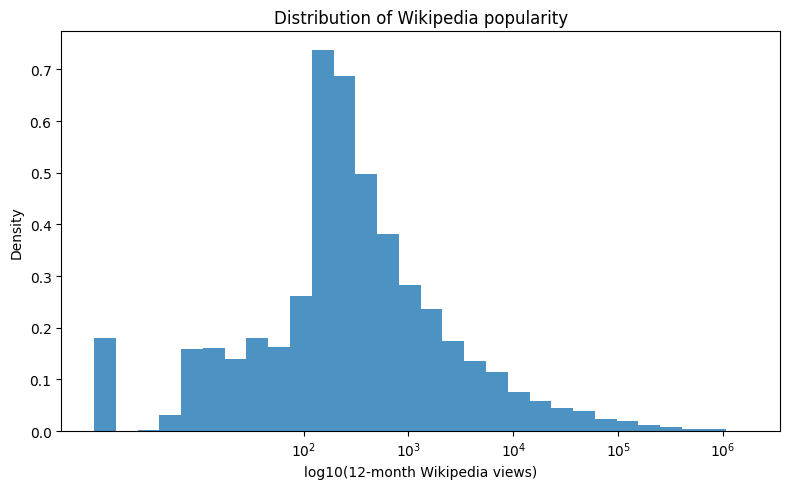

In [132]:

popularity = (
    df_geojson.drop_duplicates("taxonid")["popularity"].apply(pd.to_numeric, errors="coerce")
    .clip(lower=1)
)

log_views = np.log10(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    log_views,
    bins=30,
    density=True,
    alpha=0.8,
)

ax.set_xlabel("log10(12-month Wikipedia views)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wikipedia popularity")

# nicer tick labels
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{t}$" for t in ticks])

plt.tight_layout()
plt.show()

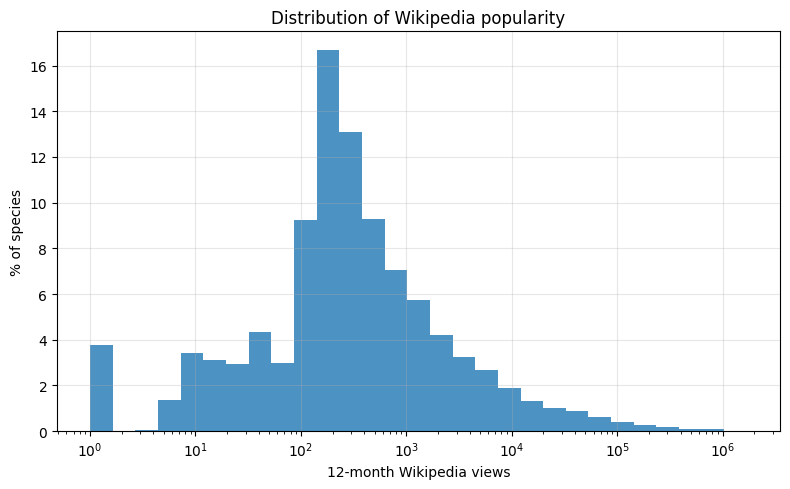

In [133]:

popularity = (
    df_geojson.drop_duplicates("taxonid")["popularity"].apply(pd.to_numeric, errors="coerce")
    .clip(lower=1)
)

bins = np.logspace(
    np.log10(popularity.min()),
    np.log10(popularity.max()),
    30
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    popularity,
    bins=bins,
    weights=np.full(len(popularity), 100 / len(popularity)),
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("% of species")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

count    1.635200e+04
mean     5.047205e+03
std      4.024113e+04
min      1.000000e+00
50%      2.470000e+02
75%      8.452500e+02
90%      4.114800e+03
95%      1.153795e+04
99%      9.740860e+04
max      1.708438e+06
Name: popularity, dtype: float64


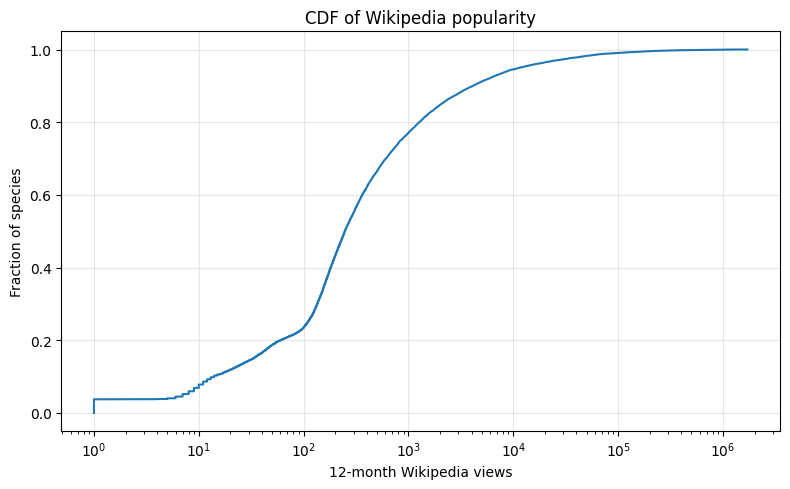

In [134]:

popularity = (
    df_geojson.drop_duplicates("taxonid")["popularity"].apply(pd.to_numeric, errors="coerce")
    .clip(lower=1)
    .sort_values()
)

y = np.arange(1, len(popularity) + 1) / len(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(popularity, y)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("Fraction of species")
ax.set_title("CDF of Wikipedia popularity")

ax.grid(alpha=0.3)

print(popularity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.tight_layout()
plt.show()

### Manual edits

In [135]:
# Display centroids for a species
CENTROID_NAME = "Whale Shark"  # common name, scientific name, or label

_q = CENTROID_NAME.casefold()
_centroid_hits = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().str.contains(_q, na=False)
].sort_values("centroid_rank")

if _centroid_hits.empty:
    print(f"'{CENTROID_NAME}' not found in df_geojson.")
else:
    _centroid_cols = [c for c in ["taxonid", "label", "scientific_name", "centroid_rank",
        "centroid_count", "centroid_source", "range_cluster_area_share", "lat", "lon"] if c in _centroid_hits.columns]
    display(_centroid_hits[_centroid_cols])

,taxonid,label,scientific_name,centroid_rank,centroid_count,centroid_source,range_cluster_area_share,lat,lon
2916,19488,Whale Shark (Rhincodon typus),Rhincodon typus,1,2,range_polygon,0.580766,2.3115,-89.7666
2917,19488,Whale Shark (Rhincodon typus),Rhincodon typus,2,2,range_polygon,0.419234,3.4309,152.8168


In [136]:
# Invert centroid order for the species found above
if _centroid_hits.empty:
    print("Run the display cell above first.")
else:
    _taxonid = int(_centroid_hits.iloc[0]["taxonid"])
    with open(ANIMALS_PATH, encoding="utf-8") as _f:
        _gj = json.load(_f)

    _taxon_feats = [f for f in _gj["features"] if (f.get("properties") or {}).get("taxonid") == _taxonid]
    _max_rank = max((f["properties"].get("centroid_rank") or 1) for f in _taxon_feats)

    for _feat in _taxon_feats:
        _r = _feat["properties"].get("centroid_rank") or 1
        _feat["properties"]["centroid_rank"] = _max_rank + 1 - _r

    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f)

    _mask = df_geojson["taxonid"].astype(str) == str(_taxonid)
    df_geojson.loc[_mask, "centroid_rank"] = df_geojson.loc[_mask, "centroid_rank"].apply(lambda r: _max_rank + 1 - int(r))

    print(f"Inverted {len(_taxon_feats)} centroid(s) for taxonid={_taxonid} in {ANIMALS_PATH}")
    display(df_geojson[_mask][_centroid_cols].sort_values("centroid_rank"))

Inverted 2 centroid(s) for taxonid=19488 in /Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson


,taxonid,label,scientific_name,centroid_rank,centroid_count,centroid_source,range_cluster_area_share,lat,lon
2917,19488,Whale Shark (Rhincodon typus),Rhincodon typus,1,2,range_polygon,0.419234,3.4309,152.8168
2916,19488,Whale Shark (Rhincodon typus),Rhincodon typus,2,2,range_polygon,0.580766,2.3115,-89.7666


In [137]:
# Reassign MALACOSTRACA to Crustaceans, Molluscs group; rename remaining Other to Reptiles, Amphibians.
# Operates on _gj (in memory) and saves to ANIMALS_PATH. Run the search/load cell above first.

_n_crust = _n_other = 0
for _feat in _gj["features"]:
    _p = _feat.get("properties") or {}
    if "Other" not in str(_p.get("taxon_group") or ""):
        continue
    if (_p.get("taxon_class") or "").upper() == "MALACOSTRACA":
        _p["taxon_group"] = "Crustaceans, Molluscs, Corals (not comprehensive)"
        _n_crust += 1
    else:
        _p["taxon_group"] = "Reptiles, Amphibians"
        _n_other += 1

with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
    json.dump(_gj, _f, ensure_ascii=False)

# Mirror into df_geojson
if "taxon_class" in df_geojson.columns:
    _mala = df_geojson["taxon_group"].str.contains("Other", na=False) & df_geojson["taxon_class"].str.upper().eq("MALACOSTRACA")
    _rest = df_geojson["taxon_group"].str.contains("Other", na=False) & ~_mala
    df_geojson.loc[_mala, "taxon_group"] = "Crustaceans, Molluscs, Corals (not comprehensive)"
    df_geojson.loc[_rest, "taxon_group"] = "Reptiles, Amphibians"

print(f"Crustaceans, Molluscs: {_n_crust} features reassigned")
print(f"Reptiles, Amphibians: {_n_other} features renamed")
print(f"Saved to {ANIMALS_PATH}")

Crustaceans, Molluscs: 504 features reassigned
Reptiles, Amphibians: 5726 features renamed
Saved to /Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson


In [138]:
# All Commons images from df_geojson — scrollable, clickable

_commons = df_geojson[
    df_geojson["image_source"].str.contains("Commons", na=False) &
    df_geojson["image_url"].notna()
].drop_duplicates(subset="taxonid").sort_values("label")

print(f"{len(_commons):,} taxa with Commons images")

_cells = []
for _, r in _commons.iterrows():
    img = r.get("image_url") or ""
    page = r.get("commons_image_page_url") or img
    name = str(r.get("label") or r.get("scientific_name") or "")
    wiki = str(r.get("wiki_url") or "")
    name_html = f"<a href='{wiki}' target='_blank'>{name}</a>" if wiki else name
    _raw_title = str(r.get("commons_image_title") or "")
    _stem = _raw_title.replace("File:", "").strip()
    # Strip extension so it can be pasted directly into _PLACEHOLDERS
    import os as _os
    img_title = _os.path.splitext(_stem)[0].replace(" ", "_")
    _cells.append(
        "<td style='padding:5px;vertical-align:top;font-size:10px;max-width:140px'>"
        + f"<a href='{page}' target='_blank'><img src='{img}' style='max-width:130px;max-height:100px;border-radius:4px;display:block'></a><br>"
        + name_html + "<br>"
        + f"<span style='color:#aaa;font-size:9px;word-break:break-all'>{img_title}</span>"
        + "</td>"
    )

rows_html = ""
for i, c in enumerate(_cells):
    if i % 5 == 0:
        rows_html += "<tr>"
    rows_html += c
    if (i + 1) % 5 == 0 or i + 1 == len(_cells):
        rows_html += "</tr>"

display(HTML(
    "<div style='max-height:600px;overflow-y:auto;border:1px solid #444;padding:8px;background:#111'>"
    + "<table>" + rows_html + "</table>"
    + "</div>"
))

457 taxa with Commons images


"Acari (Baryancistrus longipinnis)Peacock_mite,_Tuckerella_sp",Achaiohydrobia moreanaMoustos_spring_(10.3897-zookeys.1037.64038)_Figure_1,Acropora speciosa640x427-a_speciosa,Adana LoachNemacheilidae_(10.3897-zse.96.55837)_Figure_5,Afrithelphusa afzeliiAfrithelphusa_monodosa_(MNHN-IU-2008-12808)_002
Albertine OwletLake-Ihema-Bird-Flying,"Alvord ChubMohagany_Mountain,_Sheldon_National_Wildlife_Refuge,_Nevada_(11129048756)",Amaila Tropical DarterCharacidium_amaila_(Armbruster),Anatolian GhizaniRhodes_Aquarium_-_Ladigesocypris_ghigii,Ancylus scalariformisFreshwater_Snail_(Ancylus_scalariformis)
Annual KillifishAustrolebias_(10.3897-zse.94.29115)_Figure_3,Annual Tropical Killifish (Leptolebias marmoratus)Leptopanchax_opalescens_(10.3897-zoologia.37.e54982)_Figures_1–2,Annual Tropical Killifish (Leptopanchax splendens)Leptopanchax_(10.3897-zookeys.867.34034)_Figure_2,"Aphyocharacidium melandetumThe_freshwater_fishes_of_British_Guiana,_including_a_study_of_the_ecological_grouping_of_species_and_the_relation_of_the_fauna_of_the_plateau_to_that_of_the_lowlands_(1912)_(14584261389)",Aracu (Leporinus guttatus)Brasão_de_Araçu
Aracu (Leporinus pitingai)Brasão_de_Araçu,Armored CatfishCorydoras_Sterbai,Ashy-Tailed SwiftChaetura_meridionalis-Sick's_Swift,AslaAmerican_Society_of_Landscape_Architects_plaque_on_headquarters_building,Astyanax daguaeTetragonopterus_daguae_illustration_(1917)
Bagre (Aguarunichthys tocantinsensis)Potamodromous_fishes_from_the_Tocantins-Araguaia_Basin,Bagre (Rhamdella aymarae)Bagre_marinus_(line_art),Bagre (Rhamdiopsis microcephala)Bagre_marinus_(line_art),Bagre (Trichomycterus taeniops)Bagre_marinus_(line_art),Bagre (Trichomycterus weyrauchi)Bagre_marinus_(line_art)
Bagre De Torrente (Astroblepus fissidens)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Astroblepus formosus)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Astroblepus supramollis)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Trichomycterus belensis)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Trichomycterus minus)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078
Bagre De Torrente (Trichomycterus ramosus)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Trichomycterus tenuis)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre De Torrente (Trichomycterus varii)Astroblepus-Pimelodes-Humboldt-Zoologie-T07p078,Bagre PintadoTrichomycterus_areolatus,Banded RockcodCephalopholis_sexmaculata_Maldives
"BanjoFestival_of_the_Winds,_LXIX_-_Morris_troupe_-_Bondi_Beach,_2013",Banjo Catfish (Xyliphius barbatus)Bunocephalichthys_verrucosus_verrucosus_seitenansicht,Barbodes ivisPuntius_binotatus_090510_0125_kdBdk,Barbonymus platysomaBarbodes_platysoma_Bleeker,"Barbudo (Imparfinis lineatus)Presentación_de_la_princesa,_Salvador_Sánchez_Barbudo"
Barrigudinho (Cnesterodon hypselurus)Gefleckter_Kaudi_Männchen,Barrigudinho (Cnesterodon omorgmatos)Gefleckter_Kaudi_Männchen,Barrigudinho (Cnesterodon septentrionalis)Gefleckter_Kaudi_Männchen,Barrigudinho (Pamphorichthys pertapeh)Gefleckter_Kaudi_Männchen,Barrigudinho (Phalloptychus eigenmanni)Annals_of_the_Carnegie_Museum_(1916)_(18413205745)
Bayou DarterAmerican_malacological_bulletin_(1986)_(18152655652),"Belgrandie De Fontaine-De-VaucluseNaturalis_Biodiversity_Center_-_RMNH.MOL.163096_-_Belgrandia_sorgica_(Coutagne,_1881)_-_Hydrobiidae_-_Mollusc_shell",Beringo (Gymnotus choco)Bering_Sea_sunset_-_NOAA,Beyşehir GudgeonGobio_gobio,Beyşehir NaseChondrostoma_(10.3897-zse.97.63691)_Figure_6
BiaNCI_Visuals_Food_Beer,"Biomphalaria smithiNaturalis_Biodiversity_Center_-_RMNH.MOL.238627_1_-_Biomphalaria_smithi_Preston,_1910_-_Planorbidae_-_Mollusc_shell","Bithynia badiella (Bithynia badiella)Naturalis_Biodiversity_Center_-_RMNH.MOL.163287_1_-_Bithynia_badiella_(Küster,_1852)_-_Bithyniidae_-_Mollusc_shell",Black Sea Pelagic PipefishSyngnathidae_-_Syngnathus_phlegon,Blackmouth CroakerBycatch_fish_species_(10.3897-zookeys.843.32410)_Figure_4


In [139]:
# Drop image URLs containing known placeholder strings (e.g. missing-image defaults).
# Add entries to _PLACEHOLDERS as new ones are discovered.
# Operates on _gj in memory and saves to ANIMALS_PATH. Run the search/load cell above first.

_PLACEHOLDERS = [
    "Falta_imagem_aves",       # Portuguese: missing bird image
    "Nuvola_apps_error",       # Wikimedia error icon
    "Córrego_Água_Limpa",
    "Muziri_Bembe",
    "Pa_Sak_River_bridge_in_Ayuttaya",
    "_France-Canada_-_058",
    "MalayArchipelago",
    "ID_Seram_(cropped",
    "Triakis_(genus)",
    "Spondias_dulcis_(2)",
    "Nguyen_Trai",
    "Карта_поширення_Alburnus_schischkovi",
    "Wappen_Laucha_an_der_Unstrut"
    "Karachi_from_above",
    "Ovas_de_curimatã",
    "The_Effect_of_the_Removal_of_a_Keystone_Species",
    "Illu_muscle_tissues",
    "Serrasanquirico11",
    "Scyliorhinidae_(10.3897",
    "Ndica",
    "Shoreline_(23776849142",
    "_Gornji_Križ_1957",
    "A_Colação_de_grau_na_Faculdade_de_Direito_de_Recife",
    "3185_Dioscorea_bulbifera",
    "ID_Talaud_islands",
    "Missing_",
    "Salinas_de_Garcí_Mendoza_Klimadiagramm",
    "2814153094769%29",
    "ID_Seram_(cropped)",
    "Crunomys_group_Sulawesi",
    "Llorona",
    "Kiloran_Bay_",
    "2021_01_16_Friedhofskapelle_Grefrath_",
    "Order-of-the-Red-Star",
    "Original_Ramen",
    "Sheldon_National_Wildlife_Refuge",
    "Dumbara_Waterfall",
    "American_malacological_bulletin_",
    "Popularity_of_name_Juana",
    "Jacundá_Centro",
    "Brasao_lambari_mg100",
    "Brasão_de_Araçu",
    "Moustos_spring_"
    "A_Colação_de_grau_na_Faculdade_de_Direito_de_Recife",
    "Ovas_de_curimatã",
    "NCI_Visuals_Food_Beer",
    "2C_Salvador_Sánchez_Barbudo",
    "2C_calendar_systems",
    "Festival_of_the_Winds",
    "Provincia_de_Misiones_",
    "Rocky_shore_at_the_St_Mary",
    "File:Puye",
    "Steve_Fraley_moving_bags_of_spotfin_chubs_to_the_banks_of_the_Cheoah_River_",
    "Deep_fried_catfish",
    "Oo_1260430"
]

_IMAGE_FIELDS = ["image_url", "wikidata_image_url", "wikipedia_thumbnail_url", "commons_image_url"]

import urllib.parse as _urlparse
_n = 0
for _feat in _gj["features"]:
    _p = _feat.get("properties") or {}
    for _field in _IMAGE_FIELDS:
        _val = _urlparse.unquote(str(_p.get(_field) or ""))
        if any(_ph in _val for _ph in _PLACEHOLDERS):
            print(f"  taxonid={_p.get('taxonid')}  {_field}: {_val}")
            _p[_field] = None
            _n += 1

with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
    json.dump(_gj, _f, ensure_ascii=False)

# Mirror into df_geojson
import re as _re
_pattern = "|".join(_re.escape(_ph) for _ph in _PLACEHOLDERS)
for _field in _IMAGE_FIELDS:
    if _field in df_geojson.columns:
        _decoded = df_geojson[_field].apply(lambda v: _urlparse.unquote(str(v)) if pd.notna(v) else "")
        _mask = _decoded.str.contains(_pattern, na=False, regex=True)
        df_geojson.loc[_mask, _field] = None

print(f"Cleared {_n} placeholder image URL(s) across {len(_PLACEHOLDERS)} known placeholder pattern(s)")

  taxonid=22723648  image_url: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/2021_01_16_Friedhofskapelle_Grefrath_(1).jpg/960px-2021_01_16_Friedhofskapelle_Grefrath_(1).jpg
  taxonid=22723648  commons_image_url: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/2021_01_16_Friedhofskapelle_Grefrath_(1).jpg/960px-2021_01_16_Friedhofskapelle_Grefrath_(1).jpg
  taxonid=22728616  image_url: https://upload.wikimedia.org/wikipedia/commons/e/e5/ID_Talaud_islands.PNG
  taxonid=22728616  wikipedia_thumbnail_url: https://upload.wikimedia.org/wikipedia/commons/e/e5/ID_Talaud_islands.PNG
  taxonid=22733672  image_url: https://upload.wikimedia.org/wikipedia/commons/b/bd/ID_Seram_(cropped).PNG
  taxonid=22733672  commons_image_url: https://upload.wikimedia.org/wikipedia/commons/b/bd/ID_Seram_(cropped).PNG
  taxonid=5368  image_url: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Shoreline_(23776849142).jpg/960px-Shoreline_(23776849142).jpg
  taxonid=5368  commons_image_u

In [140]:
# Check if any wiki article URLs contain a keyword
WIKI_URL_KEYWORD = "nancy"

_wiki_hits = df_geojson[
    df_geojson["wiki_url"].str.contains(WIKI_URL_KEYWORD, case=False, na=False)
].drop_duplicates(subset="taxonid")

print(f"Taxa whose wiki_url contains {WIKI_URL_KEYWORD!r}: {len(_wiki_hits):,}")
if not _wiki_hits.empty:
    _cols = [c for c in ["taxonid", "label", "scientific_name", "wiki_url", "popularity"] if c in _wiki_hits.columns]
    with pd.option_context("display.max_colwidth", 120):
        display(_wiki_hits[_cols])

Taxa whose wiki_url contains 'nancy': 4


,taxonid,label,scientific_name,wiki_url,popularity
4658,186519,Matilebias juanlangi,Matilebias juanlangi,"https://en.wikipedia.org/wiki/Nancy,_France",124180
8306,41540,Nancy Ma’S Night Monkey,Aotus nancymaae,https://en.wikipedia.org/wiki/Nancy_Ma%27s_night_monkey,3676
8655,70610874,Saguinus ursulus,Saguinus ursulus,https://en.wikipedia.org/wiki/Nancy_(given_name),27356
13852,172788,Trachylepis nancycoutuae,Trachylepis nancycoutuae,https://en.wikipedia.org/wiki/Trachylepis_nancycoutuae,240


In [141]:
# Clear Wikipedia article for taxa whose wiki_url contains any of the keywords below.
# wiki_url, wiki_title, wiki_project → None (no clickable link in popup label)
# wikipedia_thumbnail_url → None; image_url cleared only if it came from Wikipedia thumbnail
# popularity → 1 (same as other taxa with no wiki article)
WIKI_URL_BLACKLIST = [
    "Nancy_(given_name)",
    "Nancy,_France"
]

_mask_clear = df_geojson["wiki_url"].apply(
    lambda v: any(kw in str(v) for kw in WIKI_URL_BLACKLIST) if pd.notna(v) else False
)
_affected_tids = set(df_geojson.loc[_mask_clear, "taxonid"].astype(str))

if not _affected_tids:
    print("No taxa found matching the blacklist keywords.")
else:
    _n = 0
    for _feat in _gj["features"]:
        _p = _feat.get("properties") or {}
        if str(_p.get("taxonid")) not in _affected_tids:
            continue
        for _f in ["wiki_url", "wiki_title", "wiki_project", "wikipedia_thumbnail_url"]:
            if _p.get(_f):
                _p[_f] = None
                _n += 1
        if (_p.get("image_source") or "").lower().startswith("wikipedia"):
            _p["image_url"] = None
            _p["image_source"] = None
        _p["popularity"] = 1

    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f, ensure_ascii=False)

    for _f in ["wiki_url", "wiki_title", "wiki_project", "wikipedia_thumbnail_url"]:
        if _f in df_geojson.columns:
            df_geojson.loc[_mask_clear, _f] = None
    _wiki_img_mask = _mask_clear & df_geojson.get("image_source", pd.Series(dtype=str)).str.lower().str.startswith("wikipedia", na=False)
    df_geojson.loc[_wiki_img_mask, "image_url"] = None
    df_geojson.loc[_wiki_img_mask, "image_source"] = None
    df_geojson.loc[_mask_clear, "popularity"] = 1

    print(f"Cleared wiki article fields for {len(_affected_tids)} taxa ({_n} fields nulled). Saved to {ANIMALS_PATH}")
    display(df_geojson.loc[_mask_clear, ["taxonid", "label", "scientific_name"]].drop_duplicates(subset="taxonid"))

Cleared wiki article fields for 2 taxa (8 fields nulled). Saved to /Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson


,taxonid,label,scientific_name
4658,186519,Matilebias juanlangi,Matilebias juanlangi
8655,70610874,Saguinus ursulus,Saguinus ursulus


In [152]:
# Find species sharing the exact same centroid coordinates as another species.
# MapLibre shows only the most popular at a shared point.
_primary = df_geojson[df_geojson["centroid_rank"].fillna(1).astype(int) == 1]
_dup_coords = _primary[_primary[["lat", "lon"]].duplicated(keep=False)]
_dup_coords = _dup_coords.drop_duplicates(subset="taxonid").sort_values(["lat", "lon"])
print(f"Taxa sharing a centroid with another taxon: {len(_dup_coords):,}")
if not _dup_coords.empty:
    _cols = [c for c in ["taxonid", "label", "scientific_name", "lat", "lon", "centroid_rank", "popularity", "centroid_source"] if c in _dup_coords.columns]
    display(_dup_coords[_cols])

Taxa sharing a centroid with another taxon: 3


,taxonid,label,scientific_name,lat,lon,centroid_rank,popularity,centroid_source
2205,103707785,Taveuni Silktail (Lamprolia victoriae),Lamprolia victoriae,-16.8487,-179.9375,1,1003,range_polygon
2210,103710745,Taveuni Streaked Fantail (Rhipidura rufilatera...,Rhipidura rufilateralis,-16.8487,-179.9375,1,14,range_polygon
2212,103711173,Azure-Crested Flycatcher (Myiagra azureocapilla),Myiagra azureocapilla,-16.8487,-179.9375,1,934,range_polygon


In [153]:
# For taxa sharing a centroid, replace it with a random interior point of their largest polygon.
# Loads from simplified spatial GeoJSON files. Run the check cell above first.

def _random_point_in_polygon(polygon, seed=None):
    """Return a random interior point of a polygon using rejection sampling."""
    rng = random.Random(seed)
    minx, miny, maxx, maxy = polygon.bounds
    for _ in range(2000):
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if polygon.contains(p):
            return p
    return polygon.representative_point()  # fallback

if _dup_coords.empty:
    print("No shared centroids — run the check cell above first.")
else:
    # Load all simplified spatial files and index by taxonid → largest polygon
    _spatial_files = sorted(glob.glob("data/processed/iucn_spatial_clean_*_simplified.geojson"))
    print(f"Loading {len(_spatial_files)} simplified spatial files...")
    _poly_map = {}  # taxonid -> largest polygon geometry
    for _sf in _spatial_files:
        with open(_sf) as _f:
            _sgj = json.load(_f)
        for _feat in _sgj["features"]:
            _tid = str((_feat.get("properties") or {}).get("id_no") or (_feat.get("properties") or {}).get("taxonid") or "")
            if not _tid or _tid not in set(_dup_coords["taxonid"].astype(str)):
                continue
            _geom = shape(_feat["geometry"])
            if _tid not in _poly_map or _geom.area > _poly_map[_tid].area:
                _poly_map[_tid] = _geom
    print(f"Found polygons for {len(_poly_map):,} / {len(_dup_coords):,} affected taxa")

    _n_fixed = 0
    for _feat in _gj["features"]:
        _p = _feat.get("properties") or {}
        _tid = str(_p.get("taxonid") or "")
        if _tid not in _poly_map:
            continue
        if int(_p.get("centroid_rank") or 1) != 1:
            continue
        _pt = _random_point_in_polygon(_poly_map[_tid], seed=int(_tid))
        _feat["geometry"]["coordinates"] = [round(_pt.x, 4), round(_pt.y, 4)]
        _p["lon"] = round(_pt.x, 4)
        _p["lat"] = round(_pt.y, 4)
        _n_fixed += 1

    with open(ANIMALS_PATH, "w", encoding="utf-8") as _f:
        json.dump(_gj, _f, ensure_ascii=False)

    # Mirror into df_geojson
    for _tid, _pt_poly in _poly_map.items():
        _pt = _random_point_in_polygon(_pt_poly, seed=int(_tid))
        _m = df_geojson["taxonid"].astype(str) == _tid
        df_geojson.loc[_m, "lon"] = round(_pt.x, 4)
        df_geojson.loc[_m, "lat"] = round(_pt.y, 4)

    print(f"Updated {_n_fixed} features. Saved to {ANIMALS_PATH}")

Loading 6 simplified spatial files...
Found polygons for 3 / 3 affected taxa
Updated 3 features. Saved to /Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson


In [154]:
# Verify no primary centroids still share exact coordinates
_primary_after = df_geojson[df_geojson["centroid_rank"].fillna(1).astype(int) == 1]
_remaining = _primary_after[_primary_after[["lat", "lon"]].duplicated(keep=False)].drop_duplicates(subset="taxonid")
if _remaining.empty:
    print("✓ No remaining shared primary centroids.")
else:
    print(f"⚠ {len(_remaining):,} taxa still share a primary centroid:")
    _cols = [c for c in ["taxonid", "label", "scientific_name", "lat", "lon"] if c in _remaining.columns]
    display(_remaining[_cols])

⚠ 3 taxa still share a primary centroid:


,taxonid,label,scientific_name,lat,lon
2205,103707785,Taveuni Silktail (Lamprolia victoriae),Lamprolia victoriae,-16.8487,-179.9375
2210,103710745,Taveuni Streaked Fantail (Rhipidura rufilatera...,Rhipidura rufilateralis,-16.8487,-179.9375
2212,103711173,Azure-Crested Flycatcher (Myiagra azureocapilla),Myiagra azureocapilla,-16.8487,-179.9375


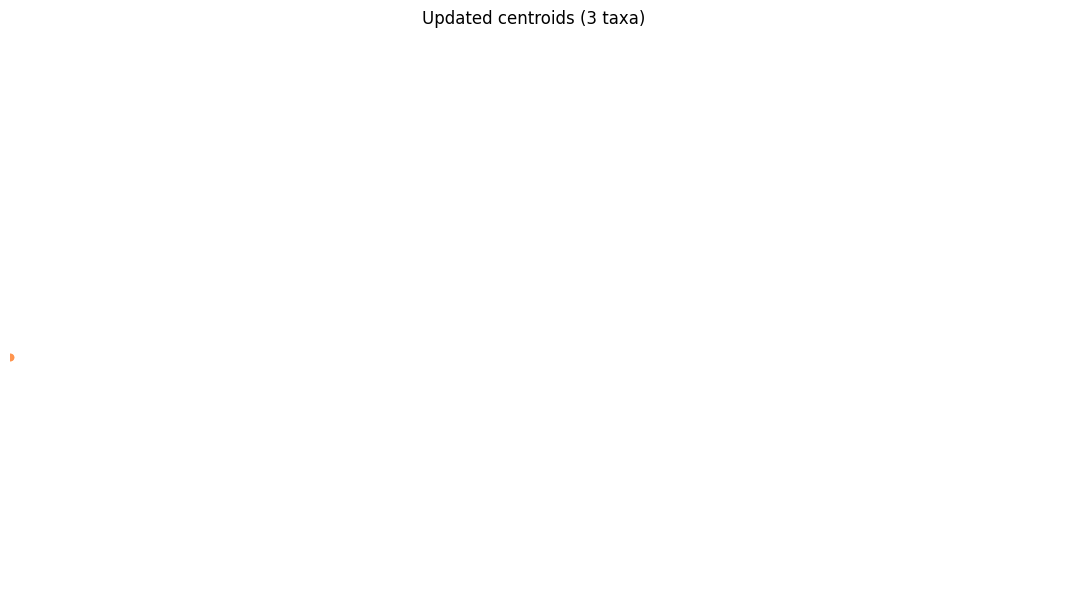

In [155]:
# Plot the updated centroids on a map
_updated_tids = set(_poly_map.keys())
_updated_rows = df_geojson[
    df_geojson["taxonid"].astype(str).isin(_updated_tids) &
    (df_geojson["centroid_rank"].fillna(1).astype(int) == 1)
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

_gdf_upd = gpd.GeoDataFrame(
    _updated_rows,
    geometry=gpd.points_from_xy(_updated_rows["lon"], _updated_rows["lat"]),
    crs="EPSG:4326"
)
_gdf_upd.plot(ax=ax, color="#FF944D", markersize=20, alpha=0.7)

ax.set_facecolor("#111")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_title(f"Updated centroids ({len(_gdf_upd):,} taxa)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [156]:
# Inspect updated centroid rows
print(f"_updated_tids: {len(_updated_tids)} taxa")
print(f"_updated_rows: {len(_updated_rows)} rows")
print()
_cols = [c for c in ["taxonid", "label", "scientific_name", "lat", "lon", "centroid_rank"] if c in _updated_rows.columns]
display(_updated_rows[_cols].head(20))

_updated_tids: 3 taxa
_updated_rows: 3 rows



,taxonid,label,scientific_name,lat,lon,centroid_rank
2205,103707785,Taveuni Silktail (Lamprolia victoriae),Lamprolia victoriae,-16.8487,-179.9375,1
2210,103710745,Taveuni Streaked Fantail (Rhipidura rufilatera...,Rhipidura rufilateralis,-16.8487,-179.9375,1
2212,103711173,Azure-Crested Flycatcher (Myiagra azureocapilla),Myiagra azureocapilla,-16.8487,-179.9375,1
